# Library


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
!pip install Sastrawi
!pip install pyLDAvis gensim
!pip install indoNLP
!pip install nlp-id


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Topic modeling & Skenario 2
import pyLDAvis
import pyLDAvis.lda_model # Changed from pyLDAvis.sklearn
import gensim
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary
from gensim.corpora.dictionary import Dictionary
# Ensure pyLDAvis is enabled for notebook display
pyLDAvis.enable_notebook()
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Skenario 3
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Skenario 4 - Slang Normalization, CountVectorizer with n-gram
from indoNLP.preprocessing import replace_slang

# Skenario 5 - StopWords and Stemming using nlp-id
from nlp_id.stopword import StopWord
from nlp_id.lemmatizer import Lemmatizer

# modeling
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split

# Load Dataset

In [ ]:
warnings.filterwarnings("ignore", category=DeprecationWarning)
df = pd.read_csv('Labeled_Dataset.csv')
df.head()

,keyword,video_id,comment,sentiment,processed_comment
0,dolar naik,D9hrcadwS-A,Budi budi kucing peliharaan meong meong🎉🎉🎉,0,budibudikucingpeliharaanmeongmeong
1,dolar naik,D9hrcadwS-A,Budiman gak pernah dikasih buat mempertebal po...,0,budimangakpernahdikasihbuatmempertebalpoinargu...
2,dolar naik,D9hrcadwS-A,Anis mah apa2an ngak jelas,0,anismahapaanngakjelas
3,dolar naik,D9hrcadwS-A,Budiman mending jadi admin jula jula aja😂,0,budimanmendingjadiadminjulajulaaja
4,dolar naik,D9hrcadwS-A,"Yang menciptakan kata omon""",0,yangmenciptakankataomon


# Topic Modeling dengan LDA

## Topic Modeling untuk Sentimen Positif

In [ ]:
warnings.filterwarnings('ignore')
df = pd.read_csv('Labeled_Dataset.csv')
df.head()

,keyword,video_id,comment,sentiment,processed_comment
0,dolar naik,D9hrcadwS-A,Budi budi kucing peliharaan meong meong🎉🎉🎉,0,budibudikucingpeliharaanmeongmeong
1,dolar naik,D9hrcadwS-A,Budiman gak pernah dikasih buat mempertebal po...,0,budimangakpernahdikasihbuatmempertebalpoinargu...
2,dolar naik,D9hrcadwS-A,Anis mah apa2an ngak jelas,0,anismahapaanngakjelas
3,dolar naik,D9hrcadwS-A,Budiman mending jadi admin jula jula aja😂,0,budimanmendingjadiadminjulajulaaja
4,dolar naik,D9hrcadwS-A,"Yang menciptakan kata omon""",0,yangmenciptakankataomon


In [ ]:
df_sentiment_2 = df[df['sentiment'] == 2]
print(df_sentiment_2.head())

       keyword     video_id  \
47  dolar naik  D9hrcadwS-A   
56  dolar naik  D9hrcadwS-A   
58  dolar naik  D9hrcadwS-A   
59  dolar naik  D9hrcadwS-A   
60  dolar naik  D9hrcadwS-A   

                                              comment  sentiment  \
47  Prof ferry mantap bisa membuat jubir pemerinta...          2   
56  Semoga Rupiah segera kembali stabil dan kondis...          2   
58  Optimis Indonesia mampu melewati tantangan glo...          2   
59  Semoga langkah yang diambil pemerintah bisa me...          2   
60  Memang kondisi global lagi berat, tapi semoga ...          2   

                                    processed_comment  
47  profferrymantapbisamembuatjubirpemerintahterta...  
56  semogarupiahsegerakembalistabildankondisiekono...  
58  optimisindonesiamampumelewatitantanganglobalka...  
59  semogalangkahyangdiambilpemerintahbisamenjagad...  
60  memangkondisigloballagiberattapisemogaindonesi...  


In [ ]:
df_sentiment_2.info()

<class 'pandas.DataFrame'>
Index: 955 entries, 47 to 16090
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   keyword            955 non-null    str  
 1   video_id           955 non-null    str  
 2   comment            955 non-null    str  
 3   sentiment          955 non-null    int64
 4   processed_comment  930 non-null    str  
dtypes: int64(1), str(4)
memory usage: 323.9 KB


DataFrame shape after preprocessing and dropping empty comments: (930, 5)
Calculating coherence for 2 topics...
Calculating coherence for 3 topics...
Calculating coherence for 4 topics...
Calculating coherence for 5 topics...
Calculating coherence for 6 topics...
Calculating coherence for 7 topics...
Calculating coherence for 8 topics...
Calculating coherence for 9 topics...
Calculating coherence for 10 topics...


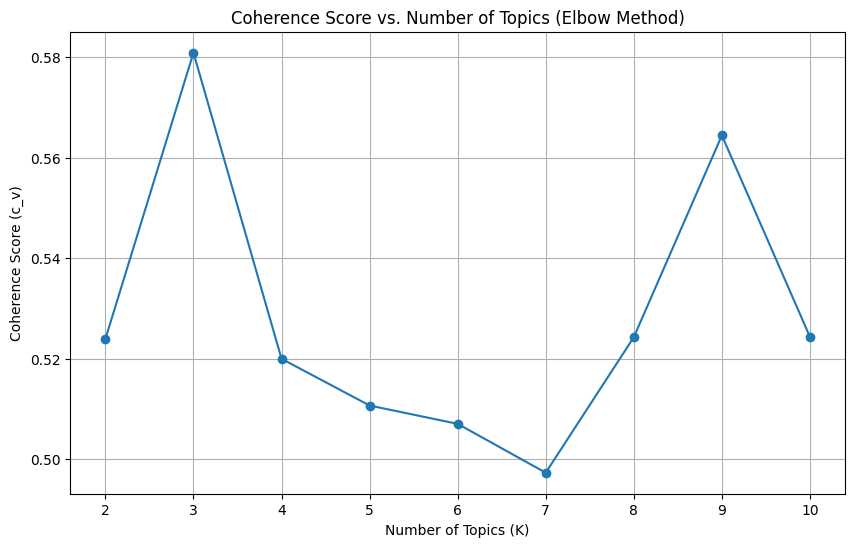


Optimal number of topics based on highest coherence score: 3
Highest coherence score: 0.5809

--- Top words for 3 topics (Optimal Model) ---
Topic 1:
dollar dolar rupiah negeri pemerintah orang barang harga desa aja pake prabowo masyarakat gak nya hidup beli pakai rakyat maju
Topic 2:
indonesia ekonomi prabowo kuat budiman masyarakat pemerintah bangsa rakyat maju membangun mandiri dolar semoga desa jaga menjaga semangat global mas
Topic 3:
indonesia imf negara rupiah asing uang amerika dunia mata rakyat bank nilai presiden ekonomi dolar tdk dgn melemah nya antek

--- Intertopic Distance Map ---


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.213725  0.092139       1        1  42.219239
2     -0.018802 -0.224254       2        1  34.988226
0     -0.194923  0.132115       3        1  22.792535, topic_info=           Term        Freq       Total Category  logprob  loglift
53          imf  225.000000  225.000000  Default  30.0000  30.0000
112      negara  189.000000  189.000000  Default  29.0000  29.0000
33       dollar   90.000000   90.000000  Default  28.0000  28.0000
56    indonesia  541.000000  541.000000  Default  27.0000  27.0000
37      ekonomi  246.000000  246.000000  Default  26.0000  26.0000
..          ...         ...         ...      ...      ...      ...
94   masyarakat   26.888226  106.869325   Topic3  -3.9385   0.0988
146    semangat   20.141593   53.584028   Topic3  -4.2274   0.5003
133     prabowo   28.847209  164.919321   Topic3  -3.8682  -0.2647
141      rakyat   23.672874  110.460437   Topic3  -4.0659  -0.0616
88         maju   21.084906   87.390500   Topic3  -4.1817   0.0569

[163 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
0         2  0.023057      aja
0         3  0.968375      aja
2         2  0.989714  amerika
3         2  0.988194    antek
5         2  0.988429    asing
...     ...       ...      ...
168       1  0.292123    turun
168       3  0.701094    turun
169       2  0.897168     uang
169       3  0.092810     uang
170       2  0.969000    utang

[187 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 3, 1])

Intertopic Distance Map saved to lda_intertopic_distance_map_positif.html


In [ ]:
# --- 1. Data Preparation ---
# Use df_sentiment_2 as the base for this analysis
df_lda = df_sentiment_2.copy()
df_lda['comment'] = df_lda['comment'].astype(str)

# Download Indonesian stopwords if not already downloaded
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

stop_words_indonesian = set(stopwords.words('indonesian'))

def preprocess_text(text):
    text = str(text).lower() # Convert to string and lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove non-alphabetic characters
    tokens = text.split()
    # Remove stopwords and very short words (e.g., single letters)
    tokens = [word for word in tokens if word not in stop_words_indonesian and len(word) > 2]
    return ' '.join(tokens)

# Apply preprocessing to the 'comment' column
df_lda['processed_comment'] = df_lda['comment'].apply(preprocess_text)

# Drop rows where 'processed_comment' is empty after preprocessing
df_lda.dropna(subset=['processed_comment'], inplace=True)
df_lda = df_lda[df_lda['processed_comment'].str.strip() != '']

print(f"DataFrame shape after preprocessing and dropping empty comments: {df_lda.shape}")

# --- 2. Determine Optimal Number of Topics using Coherence Score (Elbow Method) ---
def calculate_coherence_scores(dataframe, text_column, start=2, limit=16, step=1, max_df=0.90, min_df=0.01):
    coherence_values = []
    model_list = []
    k_values = range(start, limit, step)

    # Fit vectorizer once on the full processed data for consistency
    vectorizer = CountVectorizer(max_df=max_df, min_df=min_df, stop_words=list(stop_words_indonesian))
    dtm = vectorizer.fit_transform(dataframe[text_column])
    feature_names = vectorizer.get_feature_names_out()

    # Prepare tokenized comments for Gensim CoherenceModel
    tokenized_comments = [doc.split() for doc in dataframe[text_column]]
    # Filter tokens to only include those present in the CountVectorizer's vocabulary
    filtered_tokenized_comments = []
    vocabulary_set = set(feature_names)
    for doc_tokens in tokenized_comments:
        filtered_doc = [token for token in doc_tokens if token in vocabulary_set]
        if filtered_doc:
            filtered_tokenized_comments.append(filtered_doc)

    # Create Gensim dictionary and corpus from filtered tokens
    gensim_dictionary = Dictionary(filtered_tokenized_comments)
    corpus = [gensim_dictionary.doc2bow(doc) for doc in filtered_tokenized_comments]

    for num_topics in k_values:
        print(f"Calculating coherence for {num_topics} topics...")
        # Create and fit the LDA model
        lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
        lda_model.fit(dtm)
        model_list.append(lda_model)

        # Extract topics (words) for coherence model
        topics_words = []
        for topic in lda_model.components_:
            # Ensure no_top_words is not greater than the number of available features in the topic
            no_top_words_for_coherence = min(10, len(feature_names)) # Using 10 as default for display_topics
            top_word_indices = topic.argsort()[:-no_top_words_for_coherence - 1:-1]
            topics_words.append([feature_names[i] for i in top_word_indices])

        # Calculate coherence score
        coherence_model = CoherenceModel(topics=topics_words, texts=filtered_tokenized_comments,
                                         dictionary=gensim_dictionary, coherence='c_v')
        coherence_values.append(coherence_model.get_coherence())

    return k_values, coherence_values, model_list, dtm, vectorizer

# Calculate coherence scores for a range of topics
k_values, coherence_scores, lda_models, dtm_final, vectorizer_final = calculate_coherence_scores(
    df_lda, 'processed_comment', start=2, limit=11, step=1) # Testing from 2 to 10 topics

# Plot the coherence scores
plt.figure(figsize=(10, 6))
plt.plot(k_values, coherence_scores, marker='o')
plt.xlabel("Number of Topics (K)")
plt.ylabel("Coherence Score (c_v)")
plt.title("Coherence Score vs. Number of Topics (Elbow Method)")
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Find the optimal number of topics (can be adjusted visually from the plot)
# For programmatic selection, we'll pick the one with the highest coherence for demonstration.
optimal_num_topics_index = coherence_scores.index(max(coherence_scores))
optimal_num_topics = k_values[optimal_num_topics_index]
optimal_lda_model = lda_models[optimal_num_topics_index]

print(f"\nOptimal number of topics based on highest coherence score: {optimal_num_topics}")
print(f"Highest coherence score: {max(coherence_scores):.4f}")

# --- 3. Display Top Word Topics for the Optimal Model ---
print(f"\n--- Top words for {optimal_num_topics} topics (Optimal Model) ---")
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx + 1}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))

no_top_words = 20 # Display 10 top words for each topic
display_topics(optimal_lda_model, vectorizer_final.get_feature_names_out(), no_top_words)

# --- 4. Show and Save Intertopic Distance Map ---
print("\n--- Intertopic Distance Map ---")
# Prepare the data for pyLDAvis using the optimal LDA model, DTM, and vectorizer
pyldavis_data = pyLDAvis.lda_model.prepare(optimal_lda_model, dtm_final, vectorizer_final, mds='mmds')

# Display the visualization interactively in the notebook
display(pyldavis_data)

# Save the visualization as an HTML file
output_filename = 'lda_intertopic_distance_map_positif.html'
pyLDAvis.save_html(pyldavis_data, output_filename)
print(f"Intertopic Distance Map saved to {output_filename}")

## Topic Modeling untuk Sentimen Negatif

In [ ]:
df = pd.read_csv('Labeled_Dataset.csv')
df.head()

,keyword,video_id,comment,sentiment,processed_comment
0,dolar naik,D9hrcadwS-A,Budi budi kucing peliharaan meong meong🎉🎉🎉,0,budibudikucingpeliharaanmeongmeong
1,dolar naik,D9hrcadwS-A,Budiman gak pernah dikasih buat mempertebal po...,0,budimangakpernahdikasihbuatmempertebalpoinargu...
2,dolar naik,D9hrcadwS-A,Anis mah apa2an ngak jelas,0,anismahapaanngakjelas
3,dolar naik,D9hrcadwS-A,Budiman mending jadi admin jula jula aja😂,0,budimanmendingjadiadminjulajulaaja
4,dolar naik,D9hrcadwS-A,"Yang menciptakan kata omon""",0,yangmenciptakankataomon


In [ ]:
df_sentiment_0 = df[df['sentiment'] == 0]
print(df_sentiment_0.head())

      keyword     video_id                                            comment  \
0  dolar naik  D9hrcadwS-A         Budi budi kucing peliharaan meong meong🎉🎉🎉   
1  dolar naik  D9hrcadwS-A  Budiman gak pernah dikasih buat mempertebal po...   
2  dolar naik  D9hrcadwS-A                         Anis mah apa2an ngak jelas   
3  dolar naik  D9hrcadwS-A          Budiman mending jadi admin jula jula aja😂   
4  dolar naik  D9hrcadwS-A                        Yang menciptakan kata omon"   

   sentiment                                  processed_comment  
0          0                 budibudikucingpeliharaanmeongmeong  
1          0  budimangakpernahdikasihbuatmempertebalpoinargu...  
2          0                              anismahapaanngakjelas  
3          0                 budimanmendingjadiadminjulajulaaja  
4          0                            yangmenciptakankataomon  


In [ ]:
df_sentiment_0.info()

<class 'pandas.DataFrame'>
Index: 14696 entries, 0 to 16147
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   keyword            14696 non-null  str  
 1   video_id           14696 non-null  str  
 2   comment            14696 non-null  str  
 3   sentiment          14696 non-null  int64
 4   processed_comment  14544 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.6 MB


DataFrame shape after preprocessing and dropping empty comments: (14512, 5)
Calculating coherence for 2 topics...
Calculating coherence for 3 topics...
Calculating coherence for 4 topics...
Calculating coherence for 5 topics...
Calculating coherence for 6 topics...
Calculating coherence for 7 topics...
Calculating coherence for 8 topics...
Calculating coherence for 9 topics...
Calculating coherence for 10 topics...


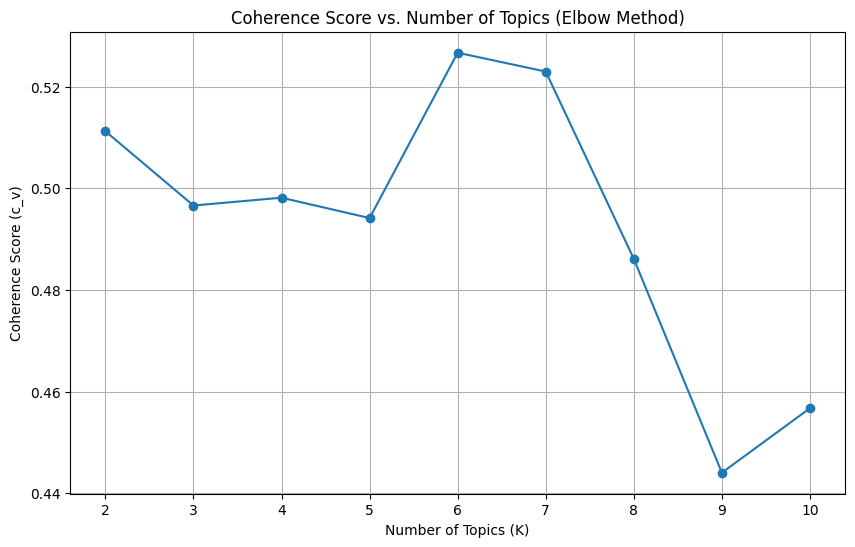


Optimal number of topics based on highest coherence score: 6
Highest coherence score: 0.5267

--- Top words for 6 topics (Optimal Model) ---
Topic 1:
presiden aja budiman anak prabowo udah ngomong paham gini banget purbaya sih wowo cerdas penjilat pintar sekelas ekonomi kayak malu
Topic 2:
presiden mbg pake desa dolar pakai nya gak dollar makan bang emang otak dah tempe goblok aja kedelai kali jago
Topic 3:
orang rakyat gak omon bodoh desa presiden nya aja tau pinter bikin pemimpin doang pidato pejabat ngomong ngerti kaya org
Topic 4:
rupiah prabowo dollar uang wowo mata nilai negara indonesia dolar imf kalo melemah asing antek impor pakai krisis lemah pemerintahan
Topic 5:
negara indonesia pemimpin ekonomi nya tdk amerika pilih salah pemerintah dgn sdh bangsa prof buzzer suka konoha korupsi semoga dunia
Topic 6:
harga nya dolar barang pemerintah rakyat beli masyarakat aja mahal bahan impor kerja turun hasil tolol biar indonesia gak kebutuhan

--- Intertopic Distance Map ---


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
4     -0.251833  0.249515       1        1  17.585577
0     -0.063047 -0.352881       2        1  17.389194
5      0.077615  0.258438       3        1  16.846940
2      0.295799  0.075097       4        1  16.617390
1      0.224214 -0.169714       5        1  16.301085
3     -0.282748 -0.060454       6        1  15.259815, topic_info=           Term         Freq        Total Category  logprob  loglift
209       orang  1427.000000  1427.000000  Default  30.0000  30.0000
254      rakyat  1570.000000  1570.000000  Default  29.0000  29.0000
258      rupiah   997.000000   997.000000  Default  28.0000  28.0000
243    presiden  2138.000000  2138.000000  Default  27.0000  27.0000
190      negara  1295.000000  1295.000000  Default  26.0000  26.0000
..          ...          ...          ...      ...      ...      ...
103   indonesia   246.667219  1345.827761   Topic6  -3.6536   0.1832
100       impor   140.219665   426.631272   Topic6  -4.2184   0.7672
215       pakai   137.845952   481.850888   Topic6  -4.2355   0.6284
223  pemerintah    97.988151   712.780588   Topic6  -4.5768  -0.1044
294        udah    94.308890   475.035765   Topic6  -4.6151   0.2631

[287 rows x 6 columns], token_table=      Topic      Freq   Term
term                        
0         1  0.039033    aja
0         2  0.450874    aja
0         3  0.181624    aja
0         4  0.176844    aja
0         5  0.115506    aja
...     ...       ...    ...
299       3  0.877857  warga
299       4  0.119320  warga
300       2  0.340222   wowo
300       5  0.001745   wowo
300       6  0.657762   wowo

[588 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 1, 6, 3, 2, 4])

Intertopic Distance Map saved to lda_intertopic_distance_map_negatif.html


In [ ]:
# --- 1. Data Preparation ---
# Use df_sentiment_0 as the base for this analysis
df_lda = df_sentiment_0.copy()
df_lda['comment'] = df_lda['comment'].astype(str)

# Download Indonesian stopwords if not already downloaded
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

stop_words_indonesian = set(stopwords.words('indonesian'))

def preprocess_text(text):
    text = str(text).lower() # Convert to string and lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove non-alphabetic characters
    tokens = text.split()
    # Remove stopwords and very short words (e.g., single letters)
    tokens = [word for word in tokens if word not in stop_words_indonesian and len(word) > 2]
    return ' '.join(tokens)

# Apply preprocessing to the 'comment' column
df_lda['processed_comment'] = df_lda['comment'].apply(preprocess_text)

# Drop rows where 'processed_comment' is empty after preprocessing
df_lda.dropna(subset=['processed_comment'], inplace=True)
df_lda = df_lda[df_lda['processed_comment'].str.strip() != '']

print(f"DataFrame shape after preprocessing and dropping empty comments: {df_lda.shape}")

# --- 2. Determine Optimal Number of Topics using Coherence Score (Elbow Method) ---
def calculate_coherence_scores(dataframe, text_column, start=2, limit=16, step=1, max_df=0.70, min_df=0.004):
    coherence_values = []
    model_list = []
    k_values = range(start, limit, step)

    # Fit vectorizer once on the full processed data for consistency
    vectorizer = CountVectorizer(max_df=max_df, min_df=min_df, stop_words=list(stop_words_indonesian))
    dtm = vectorizer.fit_transform(dataframe[text_column])
    feature_names = vectorizer.get_feature_names_out()

    # Prepare tokenized comments for Gensim CoherenceModel
    tokenized_comments = [doc.split() for doc in dataframe[text_column]]
    # Filter tokens to only include those present in the CountVectorizer's vocabulary
    filtered_tokenized_comments = []
    vocabulary_set = set(feature_names)
    for doc_tokens in tokenized_comments:
        filtered_doc = [token for token in doc_tokens if token in vocabulary_set]
        if filtered_doc:
            filtered_tokenized_comments.append(filtered_doc)

    # Create Gensim dictionary and corpus from filtered tokens
    gensim_dictionary = Dictionary(filtered_tokenized_comments)
    corpus = [gensim_dictionary.doc2bow(doc) for doc in filtered_tokenized_comments]

    for num_topics in k_values:
        print(f"Calculating coherence for {num_topics} topics...")
        # Create and fit the LDA model
        lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
        lda_model.fit(dtm)
        model_list.append(lda_model)

        # Extract topics (words) for coherence model
        topics_words = []
        for topic in lda_model.components_:
            # Ensure no_top_words is not greater than the number of available features in the topic
            no_top_words_for_coherence = min(10, len(feature_names)) # Using 10 as default for display_topics
            top_word_indices = topic.argsort()[:-no_top_words_for_coherence - 1:-1]
            topics_words.append([feature_names[i] for i in top_word_indices])

        # Calculate coherence score
        coherence_model = CoherenceModel(topics=topics_words, texts=filtered_tokenized_comments,
                                         dictionary=gensim_dictionary, coherence='c_v')
        coherence_values.append(coherence_model.get_coherence())

    return k_values, coherence_values, model_list, dtm, vectorizer

# Calculate coherence scores for a range of topics
k_values, coherence_scores, lda_models, dtm_final, vectorizer_final = calculate_coherence_scores(
    df_lda, 'processed_comment', start=2, limit=11, step=1) # Testing from 2 to 10 topics

# Plot the coherence scores
plt.figure(figsize=(10, 6))
plt.plot(k_values, coherence_scores, marker='o')
plt.xlabel("Number of Topics (K)")
plt.ylabel("Coherence Score (c_v)")
plt.title("Coherence Score vs. Number of Topics (Elbow Method)")
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Find the optimal number of topics (can be adjusted visually from the plot)
# For programmatic selection, we'll pick the one with the highest coherence for demonstration.
optimal_num_topics_index = coherence_scores.index(max(coherence_scores))
optimal_num_topics = k_values[optimal_num_topics_index]
optimal_lda_model = lda_models[optimal_num_topics_index]

print(f"\nOptimal number of topics based on highest coherence score: {optimal_num_topics}")
print(f"Highest coherence score: {max(coherence_scores):.4f}")

# --- 3. Display Top Word Topics for the Optimal Model ---
print(f"\n--- Top words for {optimal_num_topics} topics (Optimal Model) ---")
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx + 1}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))

no_top_words = 20 # Display 10 top words for each topic
display_topics(optimal_lda_model, vectorizer_final.get_feature_names_out(), no_top_words)

# --- 4. Show and Save Intertopic Distance Map ---
print("\n--- Intertopic Distance Map ---")
# Prepare the data for pyLDAvis using the optimal LDA model, DTM, and vectorizer
pyldavis_data = pyLDAvis.lda_model.prepare(optimal_lda_model, dtm_final, vectorizer_final, mds='mmds')

# Display the visualization interactively in the notebook
display(pyldavis_data)

# Save the visualization as an HTML file
output_filename = 'lda_intertopic_distance_map_negatif.html'
pyLDAvis.save_html(pyldavis_data, output_filename)
print(f"Intertopic Distance Map saved to {output_filename}")

# Handle imbalance dataset

Dalam segmen ini, kita perlu melakukan perlakuan khusus pada data yang saat ini kita miliki dikarenakan sifat datanya yang sangat condong ke satu label saja. Sehingga kita perlu mengurangi data yang memiliki label dominan dan membuat data baru untuk label yang memiliki jumlah data kecil untuk kita seimbangkan rasionya sehingga ukurannya seimbang untuk setiap label.

Perlakuan ini diperlukan agar tidak terjadinya overfitting yang diakibatkan karena model melakukan training pada dataset yang condong pada satu label saja.

Dalam bagian pre-processing ini, pertama kami melakukan split data untuk mengambil 300 data test (100 per kelas) dari raw dataset.
Lalu, kami menerapkan undersampling dan oversampling (Data Augmentation) pada data yang tersisa untuk dijadikan data train.

**Label sentiment:** 0 = Negatif, 1 = Netral, 2 = Positif

**Target:**

Rasio data = 90 : 10

Test = 300 (100 per kelas), Train = 2700 (900 per kelas)

## Cleaning Data

Hapus data duplikat yang ada di dataset agar tidak terjadi overlap (tidak ada komentar yang sama di train dan test)

In [ ]:
LABEL_NAMES = {0: 'negatif', 1: 'netral', 2: 'positif'}

print("Jumlah data awal:", df.shape)

# drop duplicate comment agar tidak ada komentar yang sama di train dan test (overlap)
df = df.drop_duplicates(subset=['comment']).reset_index(drop=True)
print("Jumlah data setelah drop duplicate comment:", df.shape)
print(df['sentiment'].value_counts().rename(index=LABEL_NAMES))

Jumlah data awal: (16148, 5)
Jumlah data setelah drop duplicate comment: (14839, 5)
sentiment
negatif    13528
positif      900
netral       411
Name: count, dtype: int64


## Ambil 300 Data Test (100 per Kelas)

Diambil manual per kelas supaya jumlahnya pasti 100/100/100.

In [ ]:
TEST_PER_CLASS = 100

test_parts, pool_parts = [], []
for label in sorted(df['sentiment'].unique()):
    class_df = df[df['sentiment'] == label]
    test_sample = class_df.sample(n=TEST_PER_CLASS, random_state=67)
    pool_sample = class_df.drop(test_sample.index)
    test_parts.append(test_sample)
    pool_parts.append(pool_sample)

df_test = pd.concat(test_parts).sample(frac=1, random_state=67).reset_index(drop=True)
df_pool = pd.concat(pool_parts).reset_index(drop=True)

X_test = df_test['comment']
y_test = df_test['sentiment']

print("=== TEST SET ===")
print("Total:", len(df_test))
print(y_test.value_counts().rename(index=LABEL_NAMES))

print("\n=== POOL TRAIN (sisa data sebelum under/oversampling) ===")
print("Total:", len(df_pool))
print(df_pool['sentiment'].value_counts().rename(index=LABEL_NAMES))

X_train_pool = df_pool['comment']
y_train_pool = df_pool['sentiment']

=== TEST SET ===
Total: 300
sentiment
positif    100
negatif    100
netral     100
Name: count, dtype: int64

=== POOL TRAIN (sisa data sebelum under/oversampling) ===
Total: 14539
sentiment
negatif    13428
positif      800
netral       311
Name: count, dtype: int64


## Undersampling

Kelas negatif (0) dipangkas ke **900**, kelas positif (1) & netral (2) dibiarkan.

In [ ]:
TARGET_PER_CLASS = 900

n_netral_pool  = (y_train_pool == 1).sum()
n_positif_pool = (y_train_pool == 2).sum()

str_undersampling = {
    0: TARGET_PER_CLASS,
    1: n_netral_pool,
    2: n_positif_pool
}

rus = RandomUnderSampler(sampling_strategy=str_undersampling, random_state=67)

X_train_pool_df = X_train_pool.to_frame()
X_train_rus, y_train_rus = rus.fit_resample(X_train_pool_df, y_train_pool)
X_train_rus = X_train_rus['comment']

print("=== SEBELUM Undersampling ===")
print(y_train_pool.value_counts().rename(index=LABEL_NAMES))

print("\n=== SETELAH Undersampling ===")
print(y_train_rus.value_counts().rename(index=LABEL_NAMES))

=== SEBELUM Undersampling ===
sentiment
negatif    13428
positif      800
netral       311
Name: count, dtype: int64

=== SETELAH Undersampling ===
sentiment
negatif    900
positif    800
netral     311
Name: count, dtype: int64


## Oversampling - Data Augmentation

Kelas positif dan netral di oversampling menjadi 900 per kelas


In [ ]:
kamus_sinonim = {
    "bagus": ["keren", "mantap", "kece", "oke", "top", "gokil"],
    "suka": ["demen", "cinta", "seneng"],
    "banget": ["sekali", "pisan", "betul", "parah"],
    "bermanfaat": ["berguna", "membantu", "edukatif"],
    "video": ["konten", "vidio", "vlog", "tayangan"],
    "jelek": ["buruk", "parah", "sampah", "kurang"],
    "setuju": ["sepakat", "bener", "valid"],
    "untung": ["cuan", "profit", "hijau", "luber", "cair", "panen"],
    "aman": ["terkendali", "stabil", "tenang", "selamat", "santai"],
    "bagus": ["mantap", "cerdas", "oke", "top", "keren", "bijak"],
    "peluang": ["kesempatan", "momen", "waktu yang pas"],
    "pemerintah": ["penguasa", "pejabat", "pusat", "pemerintahan", "negara", "pemimpin"],
    "rakyat": ["masyarakat", "warga", "kita", "rakyat kecil", "wong cilik", "umr"],
    "dollar": ["usd", "dolar", "dolar as", "uang asing", "greenback"],
    "rupiah": ["rp", "idr", "mata uang kita", "uang kita"],
    "ekonomi": ["keuangan", "finansial", "pasar", "keadaan"],
    "investasi": ["porto", "portofolio", "saham", "aset", "simpanan", "reksadana", "tabungan"],
    "beli": ["serok", "borong", "tampung", "ambil", "masuk"],
    "jual": ["lepas", "buang", "take profit", "cut loss", "keluar"],
    "tahan": ["hold", "simpan", "tunggu", "wait and see"],
    "gaji": ["pendapatan", "penghasilan", "pemasukan", "upah"],
    "lanjut": ["next", "part 2", "up", "request", "lanjutkan", "bahas ini bang"],
    "tertawa": ["ngakak", "wkwkwk", "kocak", "bengek", "awokawok", "lucu banget", "bikin mual"],
    "dukung": ["semangat", "support", "sukses terus", "maju terus", "gas", "kawal", "kembangkan"],
    "inspirasi": ["panutan", "motivasi", "teladan", "idola", "menginspirasi", "bikin melek", "buka mata"],
    "pintar": ["jenius", "suhu", "master", "pakar", "berilmu", "pro", "otak encer", "paham banget"],
    "jelas": ["paham", "mengerti", "gamblang", "masuk akal", "gampang dicerna", "mudah dipahami", "terang benderang"],
    "terimakasih": ["makasih", "thank you", "tq", "suwun", "nuhun", "thanks bang", "makasih ilmunya"],
    "hormat": ["respect", "salut", "angkat topi", "sungkem", "respek", "kelas", "luar biasa"],
    "berkualitas": ["daging semua", "premium", "bukan kaleng-kaleng", "berbobot", "bergizi", "berkelas"],
    "doa": ["amin", "berkah", "sehat selalu", "lancar rezeki", "barokah", "panjang umur", "semoga sukses"],
    "nyaman": ["adem", "healing", "bikin tenang", "betah", "enak diliat", "santuy", "vibesnya dapet"],
    "bangga": ["proud", "merinding", "terharu", "ikut seneng", "membanggakan", "terbaik"],
    "ramah": ["humble", "rendah hati", "merakyat", "sopan", "baik banget", "gak sombong"],
    "tidak": ["gak", "ga", "nggak", "g", "kagak", "ndak", "tdk"],
    "yang": ["yg"],
    "sudah": ["udah", "udh", "sdh", "dah"],
    "belum": ["belom", "blm", "blom"],
    "kalau": ["kalo", "klo", "kl", "kalu"],
    "karena": ["karna", "krn", "gara-gara", "gegara"],
    "seperti": ["kayak", "kyk", "kek", "spt"],
    "bagaimana": ["gimana", "gmn", "bgmn", "cemana"],
    "dengan": ["dgn", "ama", "sama"],
    "terus": ["trus", "trs"],
    "tapi": ["tp"],
    "bisa": ["bs", "bise"],
    "banyak": ["bnyk", "byk"],
    "sekarang": ["skrg"],
    "orang": ["org", "hooman"],
    "saja": ["aja", "aj", "sj", "za"],
    "lagi": ["lg"],
    "untuk": ["utk", "buat", "bt"],
    "sangat": ["bgt", "banget", "pisan"],
    "iya": ["y", "ya", "yoi", "yep"],
    "omon": ["omon-omon", "omong kosong", "bualan", "cakap doang", "teori saja", "banyak bicara", "pepesan kosong"],
    "buzzer": ["pendengung", "akun bayaran", "pasukan siber", "bot", "pendukung bayaran"],
    "nyebokin": ["membela", "menutupi kesalahan", "membersihkan nama", "mencari-cari alasan", "membenarkan"],
    "penjilat": ["pencari muka", "kacung", "antek", "loyalis buta", "penjilat pantat"],
    "blunder": ["salah langkah", "keliru", "salah ucap", "kesalahan fatal", "terpeleset lidah"],
    "ngawur": ["asal-asalan", "sembarangan", "melantur", "tidak masuk akal", "asbun", "asal bunyi"],
    "setingan": ["rekayasa", "buatan", "manipulasi", "pura-pura", "settingan"],
    "wowo": ["prabowo", "02", "pak prabowo", "pak presiden"],
    "keren": ["mantap", "hebat", "luar biasa", "bagus", "jempolan", "memukau"],
    "kecewa": ["tidak puas", "nyesel", "menyesal", "patah hati", "hilang harapan"],
    "bodoh": ["bego", "dungu", "tolol", "pandir", "tidak pintar", "kurang akal"],
    "kuat": ["stabil", "tangguh", "kokoh", "tahan banting", "seimbang", "normal", "mapan"],
    "optimis": ["yakin", "percaya diri", "berpikiran positif", "penuh harapan"],
    "hancur": ["rusak", "binasa", "runtuh", "berantakan", "amburadul"],
    "panik": ["takut", "khawatir", "gelisah", "cemas"],
    "susah": ["sulit", "melarat", "miskin", "menderita"],
    "krisis": ["resesi", "kemelut", "kemerosotan", "masa sulit", "kejatuhan"],
    "ekonomi": ["perekonomian", "finansial", "keuangan"],
    "utang": ["hutang", "pinjaman", "tunggakan", "kewajiban", "kredit"],
    "korupsi": ["rasuah", "penggelapan uang", "penyelewengan", "maling uang rakyat"],
    "pemerintah": ["penguasa", "rezim", "kabinet", "negara"],
    "rakyat": ["masyarakat", "warga", "publik", "penduduk", "orang kecil", "rayat"],
    "pejabat": ["aparatur", "birokrat", "pemimpin", "petinggi"],
    "kebijakan": ["aturan", "regulasi", "keputusan", "langkah"],
    "dukung": ["mendukung", "menyokong", "membela", "membantu", "mendorong", "memihak"],
    "menata": ["membenahi", "memperbaiki", "merapikan", "mengurus", "mengelola"],
    "melumpuhkan": ["mematahkan", "mengalahkan", "membungkam", "menundukkan"],
    "menjaga": ["merawat", "melindungi", "mempertahankan", "mengawal"],
    "bekerja": ["bertugas", "berupaya", "berusaha", "mengabdi"],
    "berjuang": ["bertarung", "berusaha keras", "mengerahkan tenaga"],
    "yg": ["yang"],
    "gk": ["gak", "nggak", "enggak", "tidak", "tdk"],
    "dng": ["dengan", "dgn"],
    "bgt": ["banget", "sekali", "pisan"],
    "mbg": ["makan bergizi gratis", "program makan siang", "makan siang gratis"],
    "oligarki": ["penguasa kapitalis", "elite politik", "kartel", "cukong"],
    "oposisi": ["tim lawan", "pihak kontra", "pengkritik", "pembangkang", "kubu lawan"],
    "bancakan": ["korupsi berjamaah", "bagi-bagi jatah", "pesta pora uang rakyat", "jarahan"],
    "amburadul": ["berantakan", "kacau balau", "carut marut", "tidak teratur", "rusak"],
    "nyinyir": ["mencibir", "mengkritik tajam", "julid", "berkomentar pedas", "asal kritik"],
    "lemot": ["lambat", "telat mikir", "tumpul", "lelet", "lamban"],
    "bodok": ["bodoh", "bego", "dungu", "tolol", "kurang akal", "pandir"],
    "downgrade": ["merendahkan", "menjatuhkan", "mengurangi nilai", "mendiskreditkan"],
    "air keras": ["ancaman fisik", "teror", "intimidasi"],
    "kestabilan": ["keseimbangan", "kemantapan", "stabilitas"],
    "tengkulak": ["pengepul", "lintah darat", "makelar", "perantara"],
    "kapitalis": ["pemilik modal", "konglomerat", "swasta besar"],
    "inflasi": ["kenaikan harga barang", "kemerosotan nilai uang", "lonjakan harga"],
    "devisa": ["cadangan uang negara", "pendapatan negara", "valuta asing"],
    "intervensi": ["campur tangan", "keterlibatan", "tindakan penstabilan", "turun tangan"],
    "mandiri": ["berdikari", "tidak bergantung", "otonom", "berdiri sendiri"],
    "bangkit": ["maju", "berkembang", "pulih", "bangun dari keterpurukan"],
    "terbungkam": ["terdiam", "mati kutu", "bungkam", "tidak bisa menjawab", "patah argumen"],
    "nyata": ["konkret", "jelas", "terbukti", "riil", "faktual"],
    "fleksibel": ["luwes", "mudah menyesuaikan", "adaptif"],
    "ga": ["gak", "nggak", "enggak", "tidak", "tdk"],
    "emg": ["memang", "emang"],
    "pd": ["pada", "daripada"],
    "utk": ["untuk", "buat"],
    "dl": ["dulu", "dahulu", "sebelumnya"],
    "ja": ["saja", "aja"]
}

def random_swap(sentence, n=1):
    """Menukar posisi dua kata secara acak di dalam kalimat."""
    words = str(sentence).split()
    if len(words) < 2: # Tidak bisa ditukar jika hanya 1 kata
        return sentence
    for _ in range(n):
        idx1, idx2 = random.sample(range(len(words)), 2)
        words[idx1], words[idx2] = words[idx2], words[idx1]
    return ' '.join(words)

def random_deletion(sentence, p=0.15):
    """Menghapus kata secara acak dengan probabilitas p."""
    words = str(sentence).split()
    if len(words) == 1: # Jangan hapus jika sisa 1 kata
        return sentence
    # Simpan kata jika probabilitas acak lebih besar dari p
    new_words = [word for word in words if random.uniform(0, 1) > p]
    if len(new_words) == 0:
        return random.choice(words)
    return ' '.join(new_words)

def synonym_replacement(sentence, kamus, n=1):
    """
    Mengganti maksimal 'n' kata dalam kalimat dengan sinonimnya.
    """
    words = str(sentence).split()
    new_words = words.copy()

    # Cari kata-kata dalam kalimat (yang diubah ke huruf kecil) yang ada di kamus
    kata_cocok = [word for word in words if word.lower() in kamus]

    # Jika tidak ada kata yang cocok dengan kamus, kembalikan kalimat asli
    if not kata_cocok:
        return sentence

    # Pilih maksimal n kata secara acak untuk diganti
    jumlah_ganti = min(n, len(kata_cocok))
    kata_yang_diganti = random.sample(kata_cocok, jumlah_ganti)

    for word in kata_yang_diganti:
        # Pilih satu sinonim secara acak dari list di kamus
        sinonim_pilihan = random.choice(kamus[word.lower()])

        # Cari posisi indeks kata tersebut dan ganti dengan sinonimnya
        for i, w in enumerate(new_words):
            if w.lower() == word.lower():
                new_words[i] = sinonim_pilihan
                break # Ganti satu saja lalu lanjut ke kata berikutnya

    return ' '.join(new_words)


def augmentasi_data_minoritas(teks_list, jumlah_target):
    """Membuat teks sintetik hingga mencapai jumlah target."""
    teks_sintetik = []
    jumlah_saat_ini = len(teks_list)
    jumlah_kekurangan = jumlah_target - jumlah_saat_ini
    counters=0
    counterm=0

    # Ubah ke list murni untuk optimasi kecepatan iterasi
    teks_list = list(teks_list)

    while len(teks_sintetik) < jumlah_kekurangan:
        # 1. Ambil teks asli secara acak dari data yang ada
        teks_asli = random.choice(teks_list)

        # 2. Pilih teknik augmentasi secara acak
        # Tambahkan [0] di akhir untuk mengekstrak string dari dalam list
        teknik = random.choices(['swap', 'delete', 'synonim'], weights=[0.2, 0, 0.8], k=1)[0]

        if teknik == 'swap':
            teks_baru = random_swap(teks_asli)
            counters = counters + 1
        elif teknik == 'synonim':
            teks_baru = synonym_replacement(teks_asli, kamus_sinonim, n=2)
            counterm = counterm + 1
        else:
            teks_baru = random_deletion(teks_asli)

        teks_sintetik.append(teks_baru)

    return teks_sintetik,counters,counterm


In [ ]:
# 1. Satukan ke DataFrame untuk memudahkan filter per kelas
df_train_rus = pd.DataFrame({'comment': X_train_rus, 'sentiment': y_train_rus})

teks_negatif = df_train_rus[df_train_rus['sentiment'] == 0]['comment']
teks_netral  = df_train_rus[df_train_rus['sentiment'] == 1]['comment']
teks_positif = df_train_rus[df_train_rus['sentiment'] == 2]['comment']

# 2. Target ekuilibrium semua kelas -> 900
TARGET_NETRAL  = TARGET_PER_CLASS
TARGET_POSITIF = TARGET_PER_CLASS

print("Mulai membuat data sintetik untuk Kelas Netral (1)...")
sintetik_netral, counter_net_swap, counter_net_syn = augmentasi_data_minoritas(teks_netral, TARGET_NETRAL)

print("Mulai membuat data sintetik untuk Kelas Positif (2)...")
sintetik_positif, counter_pos_swap, counter_pos_syn = augmentasi_data_minoritas(teks_positif, TARGET_POSITIF)

# 3. Bungkus data sintetik ke DataFrame
df_sintetik_netral  = pd.DataFrame({'comment': sintetik_netral, 'sentiment': 1})
df_sintetik_positif = pd.DataFrame({'comment': sintetik_positif, 'sentiment': 2})

# 4. Gabungkan semua data (Asli hasil Undersampling + Sintetik Baru)
df_train_final = pd.concat([
    df_train_rus[df_train_rus['sentiment'] == 0],   # negatif (hasil undersampling)
    df_train_rus[df_train_rus['sentiment'] == 1],   # netral asli (sebelum augmentasi)
    df_sintetik_netral,                              # netral sintetik
    df_train_rus[df_train_rus['sentiment'] == 2],   # positif asli (sebelum augmentasi)
    df_sintetik_positif,                             # positif sintetik
], ignore_index=True)

# 5. Shuffle supaya model tidak belajar berurutan per kelas
df_train_final = df_train_final.sample(frac=1, random_state=67).reset_index(drop=True)

x_train_final = df_train_final['comment']
y_train_final = df_train_final['sentiment']

print("\n=== Distribusi Label DATA TRAIN FINAL (balanced) ===")
print(y_train_final.value_counts().rename(index=LABEL_NAMES))

Mulai membuat data sintetik untuk Kelas Netral (1)...
Mulai membuat data sintetik untuk Kelas Positif (2)...

=== Distribusi Label DATA TRAIN FINAL (balanced) ===
sentiment
netral     900
positif    900
negatif    900
Name: count, dtype: int64


## Validasi pastiin tidak ada overlap antara data test dan train

In [ ]:
overlap = set(X_test) & set(x_train_final)
print("Jumlah komentar yang overlap antara test dan train:", len(overlap))

print("\n=== RINGKASAN AKHIR ===")
print(f"Test set  : {len(df_test)} data")
print(f"Train set : {len(df_train_final)} data")

Jumlah komentar yang overlap antara test dan train: 0

=== RINGKASAN AKHIR ===
Test set  : 300 data
Train set : 2700 data


## Simpan ke CSV

In [ ]:
x_train_final.to_csv('x_train_final.csv', index=False, encoding='utf-8')
y_train_final.to_csv('y_train_final.csv', index=False, encoding='utf-8')

X_test.to_csv('x_test_final.csv', index=False, encoding='utf-8')
y_test.to_csv('y_test_final.csv', index=False, encoding='utf-8')

# Skenario 1 - Fauzan

In [ ]:
# ==========================================
# SKENARIO 1 - Tanpa Pre-processing
# ==========================================

x1_train = x_train_final.copy()
y1_train = y_train_final.copy()

x1_test = X_test.copy()
y1_test = y_test.copy()

print("Jumlah data training :", len(x1_train))
print("Jumlah data testing  :", len(x1_test))

Jumlah data training : 2700
Jumlah data testing  : 300


In [ ]:
x1_train = x1_train.fillna('')
x1_test  = x1_test.fillna('')

vectorizer1 = TfidfVectorizer(max_features=10000)

# fit_transform pada data training (sudah di-stem)
X1_train_tfidf = vectorizer1.fit_transform(x1_train)
X1_test_tfidf   = vectorizer1.transform(x1_test)

print("Shape X3_train_tfidf :", X1_train_tfidf.shape)
print("Shape X3_test_tfidf  :", X1_test_tfidf.shape)

Shape X3_train_tfidf : (2700, 6318)
Shape X3_test_tfidf  : (300, 6318)



=== Logistic Regression ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.52      0.80      0.63       100
     Neutral       0.76      0.35      0.48       100
    Positive       0.83      0.84      0.84       100

    accuracy                           0.66       300
   macro avg       0.71      0.66      0.65       300
weighted avg       0.71      0.66      0.65       300

Confusion Matrix:


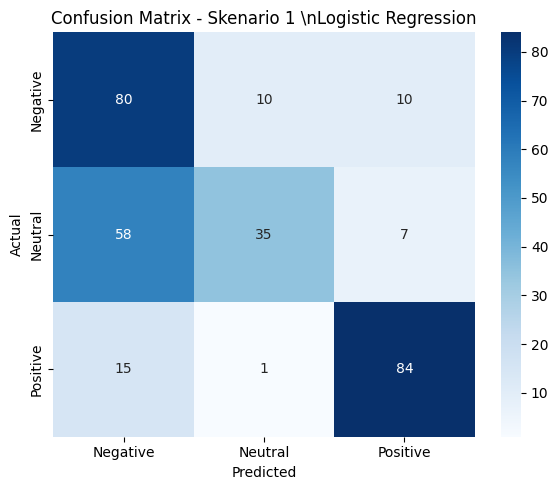


=== Multinomial Naive Bayes ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.57      0.70      0.63       100
     Neutral       0.84      0.36      0.50       100
    Positive       0.66      0.89      0.76       100

    accuracy                           0.65       300
   macro avg       0.69      0.65      0.63       300
weighted avg       0.69      0.65      0.63       300

Confusion Matrix:


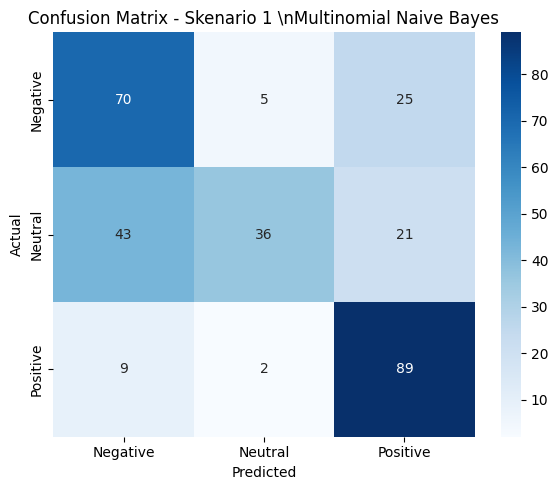


=== Support Vector Machine ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.52      0.90      0.66       100
     Neutral       0.85      0.29      0.43       100
    Positive       0.87      0.80      0.83       100

    accuracy                           0.66       300
   macro avg       0.75      0.66      0.64       300
weighted avg       0.75      0.66      0.64       300

Confusion Matrix:


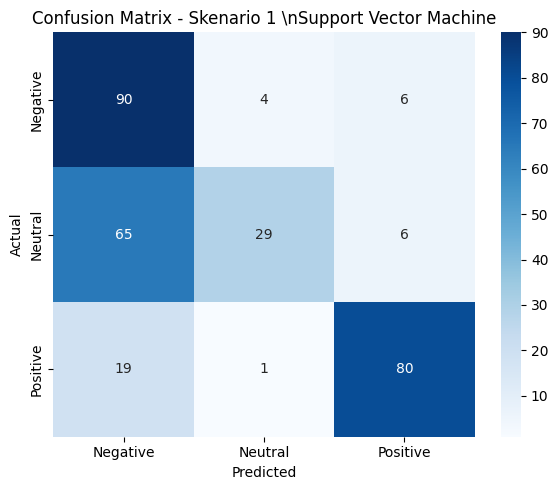


=== Random Forest ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.59      0.67      0.63       100
     Neutral       0.71      0.52      0.60       100
    Positive       0.75      0.85      0.79       100

    accuracy                           0.68       300
   macro avg       0.68      0.68      0.67       300
weighted avg       0.68      0.68      0.67       300

Confusion Matrix:


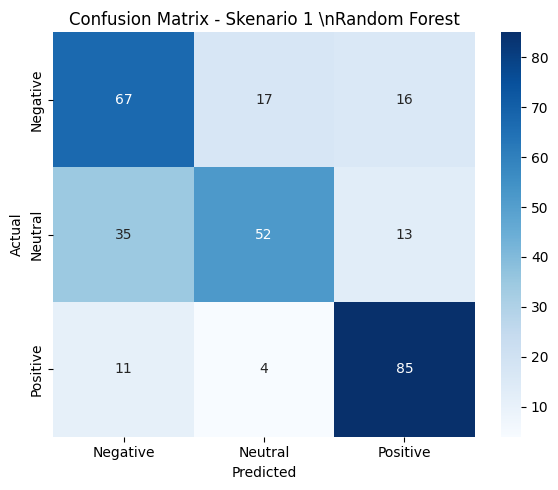


=== XGBoost ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.53      0.63      0.58       100
     Neutral       0.64      0.53      0.58       100
    Positive       0.80      0.79      0.79       100

    accuracy                           0.65       300
   macro avg       0.66      0.65      0.65       300
weighted avg       0.66      0.65      0.65       300

Confusion Matrix:


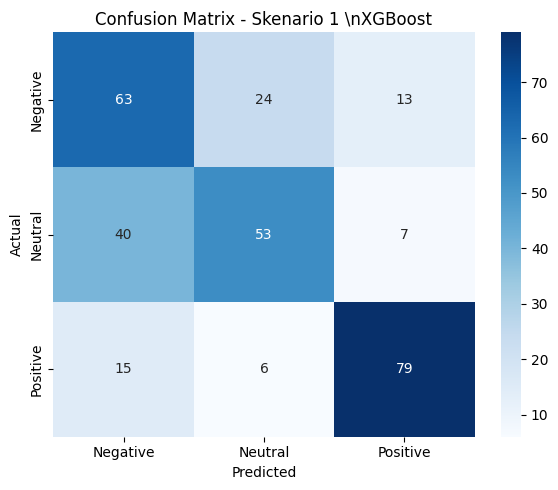


=== Perbandingan Performa Model (Skenario 1 - Stemming) ===
Metric                            Accuracy  F1-score  Precision  Recall  \
Model                   Class                                             
Logistic Regression     Negative       NaN  0.632411   0.522876    0.80   
                        Neutral        NaN  0.479452   0.760870    0.35   
                        Overall   0.663333       NaN        NaN     NaN   
                        Positive       NaN  0.835821   0.831683    0.84   
Multinomial Naive Bayes Negative       NaN  0.630631   0.573770    0.70   
                        Neutral        NaN  0.503497   0.837209    0.36   
                        Overall   0.650000       NaN        NaN     NaN   
                        Positive       NaN  0.757447   0.659259    0.89   
Random Forest           Negative       NaN  0.629108   0.592920    0.67   
                        Neutral        NaN  0.601156   0.712329    0.52   
                        Overall   0.680

In [ ]:
# ==========================================
# Training Model
# ==========================================

models1 = {
    'Logistic Regression'    : LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Support Vector Machine' : SVC(random_state=42),
    'Random Forest'          : RandomForestClassifier(random_state=42),
    'XGBoost'                : XGBClassifier(random_state=42, eval_metric='mlogloss')
}

target_names1 = ['Negative', 'Neutral', 'Positive']
results1 = []

for name, model in models1.items():
    print(f"\n=== {name} ===")

    # train
    model.fit(X1_train_tfidf, y1_train)

    # prediksi
    y1_pred = model.predict(X1_test_tfidf)

    # evaluasi
    report   = classification_report(y1_test, y1_pred, target_names=target_names1, output_dict=True)
    accuracy = accuracy_score(y1_test, y1_pred)

    for class_label in target_names1:
        for metric in ['precision', 'recall', 'f1-score', 'support']:
            results1.append({
                'Model' : name,
                'Metric': metric.replace('-score', '-Score').capitalize(),
                'Class' : class_label,
                'Score' : report[class_label][metric]
            })

    results1.append({
        'Model' : name,
        'Metric': 'Accuracy',
        'Class' : 'Overall',
        'Score' : accuracy
    })

    print("Classification Report:")
    print(classification_report(y1_test, y1_pred, target_names=target_names1))

    print("Confusion Matrix:")
    cm1 = confusion_matrix(y1_test, y1_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names1, yticklabels=target_names1)
    plt.title(f'Confusion Matrix - Skenario 1 \\n{name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

# buat dataframe perbandingan hasil
df1 = pd.DataFrame(results1)
pivot1 = df1.pivot_table(index=['Model', 'Class'], columns='Metric', values='Score')
print("\n=== Perbandingan Performa Model (Skenario 1 - Stemming) ===")
print(pivot1)

=== Ringkasan Test Accuracy (Skenario 1 - Stemming) ===
                  Model  Test Accuracy
          Random Forest       0.680000
    Logistic Regression       0.663333
 Support Vector Machine       0.663333
Multinomial Naive Bayes       0.650000
                XGBoost       0.650000


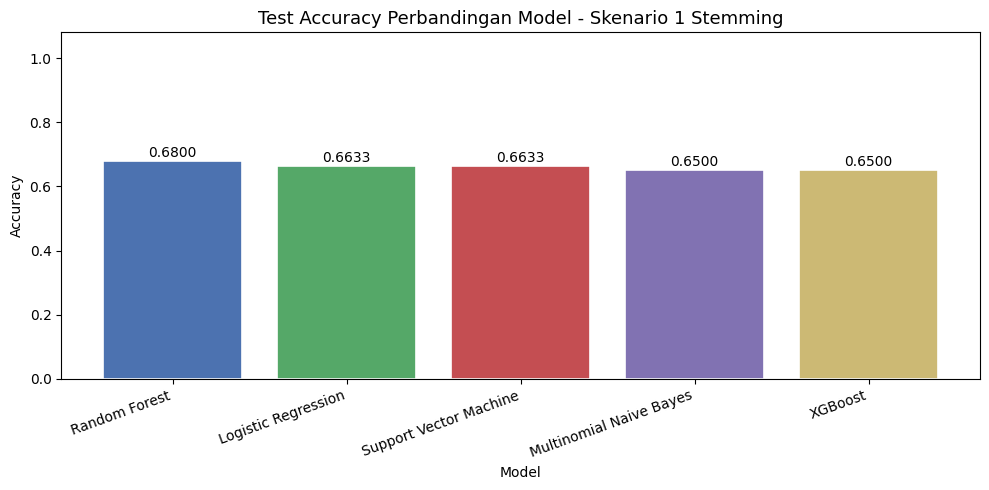

In [ ]:
# ==========================================
# Visualisasi Test Accuracy per Model
# ==========================================

accuracy1_summary = (
    df1[
        (df1['Metric'] == 'Accuracy') &
        (df1['Class']  == 'Overall')
    ][['Model', 'Score']]
    .sort_values('Score', ascending=False)
    .reset_index(drop=True)
)
accuracy1_summary.columns = ['Model', 'Test Accuracy']

print('=== Ringkasan Test Accuracy (Skenario 1 - Stemming) ===')
print(accuracy1_summary.to_string(index=False))

colors1 = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
plt.figure(figsize=(10, 5))
bars1 = plt.bar(
    accuracy1_summary['Model'],
    accuracy1_summary['Test Accuracy'],
    color=colors1[:len(accuracy1_summary)],
    edgecolor='white',
    linewidth=1.2
)
for rect in bars1:
    height = rect.get_height()
    plt.text(
        rect.get_x() + rect.get_width() / 2.,
        height + 0.003,
        f'{height:.4f}',
        ha='center', va='bottom', fontsize=10
    )
plt.title('Test Accuracy Perbandingan Model - Skenario 1 Stemming', fontsize=13)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1.08)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# Skenario 2 - Willy

In [ ]:
# ==========================================
# SKENARIO 2 - Stopwords Removal
# ==========================================

x2_train = x_train_final.copy()
y2_train = y_train_final.copy()

x2_test = X_test.copy()
y2_test = y_test.copy()

print("Jumlah data training :", len(x2_train))
print("Jumlah data testing  :", len(x2_test))

Jumlah data training : 2700
Jumlah data testing  : 300



Shape X2_train_tfidf : (2700, 5000)
Shape X2_test_tfidf  : (300, 5000)

=== Logistic Regression ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.55      0.79      0.65       100
     Neutral       0.79      0.42      0.55       100
    Positive       0.81      0.84      0.82       100

    accuracy                           0.68       300
   macro avg       0.72      0.68      0.67       300
weighted avg       0.72      0.68      0.67       300

Confusion Matrix:


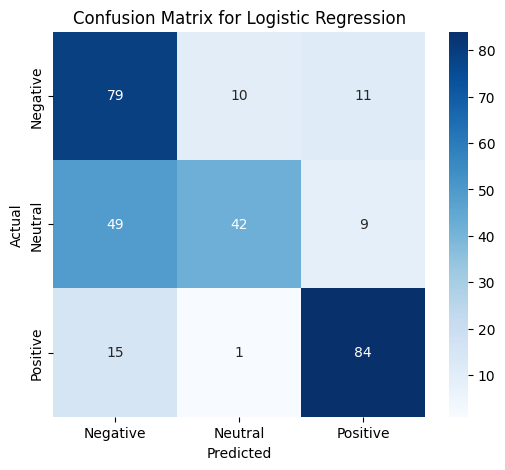


=== Multinomial Naive Bayes ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.57      0.67      0.61       100
     Neutral       0.78      0.43      0.55       100
    Positive       0.69      0.87      0.77       100

    accuracy                           0.66       300
   macro avg       0.68      0.66      0.65       300
weighted avg       0.68      0.66      0.65       300

Confusion Matrix:


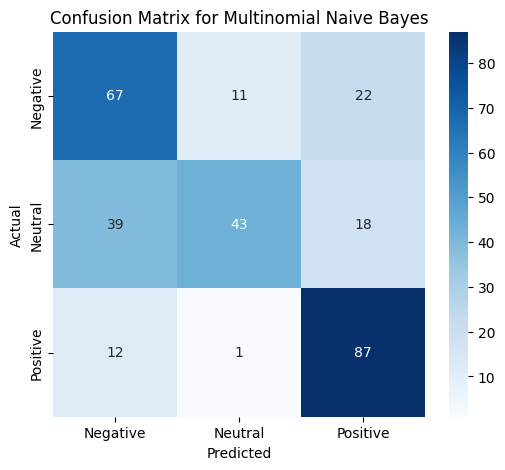


=== Support Vector Machine ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.54      0.88      0.67       100
     Neutral       0.86      0.37      0.52       100
    Positive       0.85      0.81      0.83       100

    accuracy                           0.69       300
   macro avg       0.75      0.69      0.67       300
weighted avg       0.75      0.69      0.67       300

Confusion Matrix:


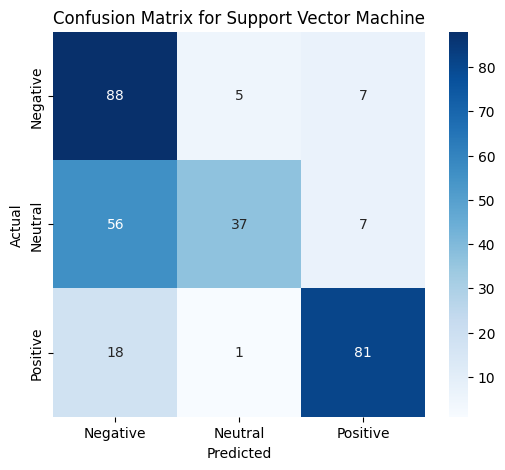


=== Random Forest ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.61      0.60      0.60       100
     Neutral       0.68      0.61      0.64       100
    Positive       0.77      0.85      0.81       100

    accuracy                           0.69       300
   macro avg       0.68      0.69      0.68       300
weighted avg       0.68      0.69      0.68       300

Confusion Matrix:


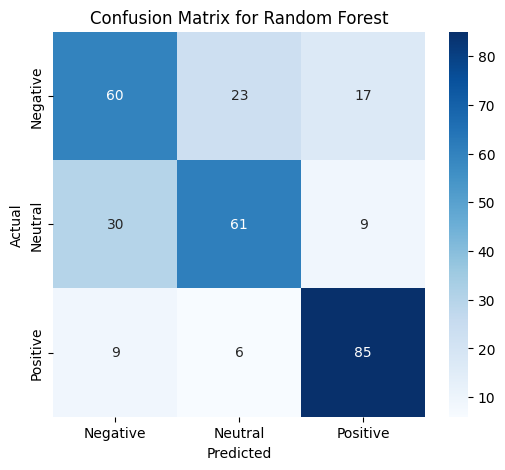


=== XGBoost ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.55      0.53      0.54       100
     Neutral       0.64      0.65      0.64       100
    Positive       0.77      0.78      0.78       100

    accuracy                           0.65       300
   macro avg       0.65      0.65      0.65       300
weighted avg       0.65      0.65      0.65       300

Confusion Matrix:


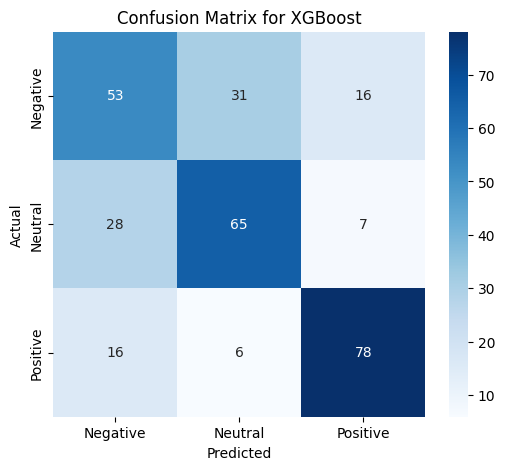


=== Model Performance Comparison ===
Metric                            Accuracy  F1-Score  Precision  Recall  \
Model                   Class                                             
Logistic Regression     Negative       NaN  0.650206   0.552448    0.79   
                        Neutral        NaN  0.549020   0.792453    0.42   
                        Overall   0.683333       NaN        NaN     NaN   
                        Positive       NaN  0.823529   0.807692    0.84   
Multinomial Naive Bayes Negative       NaN  0.614679   0.567797    0.67   
                        Neutral        NaN  0.554839   0.781818    0.43   
                        Overall   0.656667       NaN        NaN     NaN   
                        Positive       NaN  0.766520   0.685039    0.87   
Random Forest           Negative       NaN  0.603015   0.606061    0.60   
                        Neutral        NaN  0.642105   0.677778    0.61   
                        Overall   0.686667       NaN        Na

In [ ]:
import nltk
from nltk.corpus import stopwords
import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure NLTK stopwords are downloaded
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

stop_words_indonesian = set(stopwords.words('indonesian'))

def preprocess_text(text):
    text = str(text).lower()  # Convert to string and lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Remove non-alphabetic characters
    tokens = text.split()
    # Remove stopwords and very short words (e.g., single letters)
    tokens = [word for word in tokens if word not in stop_words_indonesian and len(word) > 2]
    return ' '.join(tokens)

# Apply preprocessing to the 'comment' column for training and test sets
x2_train = x2_train.apply(preprocess_text)
x2_test = x2_test.apply(preprocess_text)

# --- TF-IDF Vectorization ---
x2_train = x2_train.fillna('')
x2_test = x2_test.fillna('')

vectorizer2 = TfidfVectorizer(max_features=5000)
X2_train_tfidf = vectorizer2.fit_transform(x2_train)
X2_test_tfidf = vectorizer2.transform(x2_test)

print("\nShape X2_train_tfidf :", X2_train_tfidf.shape)
print("Shape X2_test_tfidf  :", X2_test_tfidf.shape)

# ==========================================
# Training Model
# ==========================================
models2 = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Support Vector Machine': SVC( random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss')
}

results2 = []
target_names2 = ['Negative', 'Neutral', 'Positive']

for name, model in models2.items():
    print(f"\n=== {name} ===")
    # Train the model
    model.fit(X2_train_tfidf, y2_train)

    # Make predictions
    y_pred = model.predict(X2_test_tfidf)

    # Evaluate the model
    report = classification_report(y2_test, y_pred, target_names=target_names2, output_dict=True)
    accuracy = accuracy_score(y2_test, y_pred)

    # Store results for each class
    for class_label in target_names2:
        results2.append({
            'Model': name,
            'Metric': 'Precision',
            'Class': class_label,
            'Score': report[class_label]['precision']
        })
        results2.append({
            'Model': name,
            'Metric': 'Recall',
            'Class': class_label,
            'Score': report[class_label]['recall']
        })
        results2.append({
            'Model': name,
            'Metric': 'F1-Score',
            'Class': class_label,
            'Score': report[class_label]['f1-score']
        })
        results2.append({
            'Model': name,
            'Metric': 'Support',
            'Class': class_label,
            'Score': report[class_label]['support']
        })

    # Store overall accuracy
    results2.append({
        'Model': name,
        'Metric': 'Accuracy',
        'Class': 'Overall',
        'Score': accuracy
    })

    print("Classification Report:")
    print(classification_report(y2_test, y_pred, target_names=target_names2))

    print("Confusion Matrix:")
    cm = confusion_matrix(y2_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names2, yticklabels=target_names2)
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Create a DataFrame from the results
comparison_df = pd.DataFrame(results2)

# Pivot the table for better readability
pivot_table = comparison_df.pivot_table(index=['Model', 'Class'], columns='Metric', values='Score')

print("\n=== Model Performance Comparison ===")
print(pivot_table)

=== Ringkasan Test Accuracy (Skenario 3 - Stemming) ===
                  Model  Test Accuracy
 Support Vector Machine       0.686667
          Random Forest       0.686667
    Logistic Regression       0.683333
Multinomial Naive Bayes       0.656667
                XGBoost       0.653333


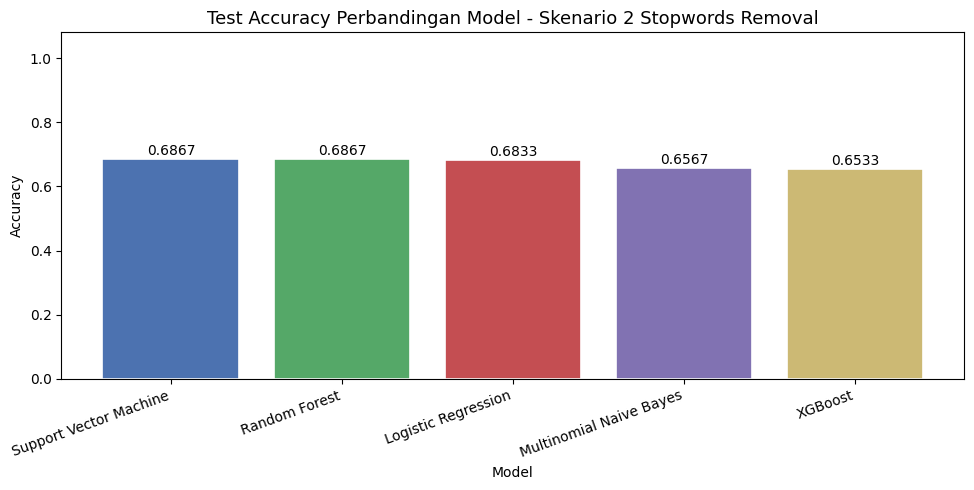

In [ ]:
# ==========================================
# Visualisasi Test Accuracy per Model
# ==========================================

accuracy2_summary = (
    comparison_df[
        (comparison_df['Metric'] == 'Accuracy') &
        (comparison_df['Class']  == 'Overall')
    ][['Model', 'Score']]
    .sort_values('Score', ascending=False)
    .reset_index(drop=True)
)
accuracy2_summary.columns = ['Model', 'Test Accuracy']

print('=== Ringkasan Test Accuracy (Skenario 3 - Stemming) ===')
print(accuracy2_summary.to_string(index=False))

colors2 = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
plt.figure(figsize=(10, 5))
bars2 = plt.bar(
    accuracy2_summary['Model'],
    accuracy2_summary['Test Accuracy'],
    color=colors2[:len(accuracy2_summary)],
    edgecolor='white',
    linewidth=1.2
)
for rect in bars2:
    height = rect.get_height()
    plt.text(
        rect.get_x() + rect.get_width() / 2.,
        height + 0.003,
        f'{height:.4f}',
        ha='center', va='bottom', fontsize=10
    )
plt.title('Test Accuracy Perbandingan Model - Skenario 2 Stopwords Removal', fontsize=13)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1.08)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# Skenario 3 - Rennard

In [ ]:
# ==========================================
# SKENARIO 3 - Preprocessing dengan Stemming
# ==========================================

x3_train = x_train_final.copy()
y3_train = y_train_final.copy()

x3_test = X_test.copy()
y3_test = y_test.copy()

print("Jumlah data training :", len(x3_train))
print("Jumlah data testing  :", len(x3_test))

Jumlah data training : 2700
Jumlah data testing  : 300


In [ ]:
# ==========================================
# Preprocessing: Stemming menggunakan PySastrawi
# Pipeline: Lowercase → Hapus noise → Tokenisasi → Stemming
# ==========================================

factory3 = StemmerFactory()
stemmer3  = factory3.create_stemmer()

def preprocess_with_stemming(text):
    # Langkah 1: Konversi ke string & lowercase
    text = str(text).lower()

    # Langkah 2: Hapus URL, mention, hashtag
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)

    # Langkah 3: Hapus karakter non-alfabet (angka, emoji, tanda baca, dst.)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Langkah 4: Tokenisasi
    tokens = text.split()

    # Langkah 5: Stemming menggunakan PySastrawi
    stemmed_tokens = [stemmer3.stem(word) for word in tokens]
    return ' '.join(stemmed_tokens)

# terapin preprocessing pada data training
x3_train = x3_train.apply(preprocess_with_stemming)
print("Contoh hasil stemming:")
print(x3_train.head())

Contoh hasil stemming:
0                                            hidup jkw
1                                      sudah itu pasti
2    imf dan warld bank adalah jebak financial untu...
3    rupiah jatuh ke level teeburuk panjang masa ih...
4                                      pikir majapahit
Name: comment, dtype: str


In [ ]:
# ==========================================
# TF-IDF Vectorization
# ==========================================

# Isi data kosong (NaN) dengan string kosong agar tidak error saat vektorisasi
x3_train = x3_train.fillna('')
x3_test  = x3_test.fillna('')

vectorizer3 = TfidfVectorizer(max_features=10000)

# fit_transform pada data training (sudah di-stem)
X3_train_tfidf = vectorizer3.fit_transform(x3_train)
X3_test_tfidf   = vectorizer3.transform(x3_test)

print("Shape X3_train_tfidf :", X3_train_tfidf.shape)
print("Shape X3_test_tfidf  :", X3_test_tfidf.shape)

Shape X3_train_tfidf : (2700, 4880)
Shape X3_test_tfidf  : (300, 4880)



=== Logistic Regression ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.53      0.73      0.61       100
     Neutral       0.69      0.40      0.51       100
    Positive       0.82      0.85      0.83       100

    accuracy                           0.66       300
   macro avg       0.68      0.66      0.65       300
weighted avg       0.68      0.66      0.65       300

Confusion Matrix:


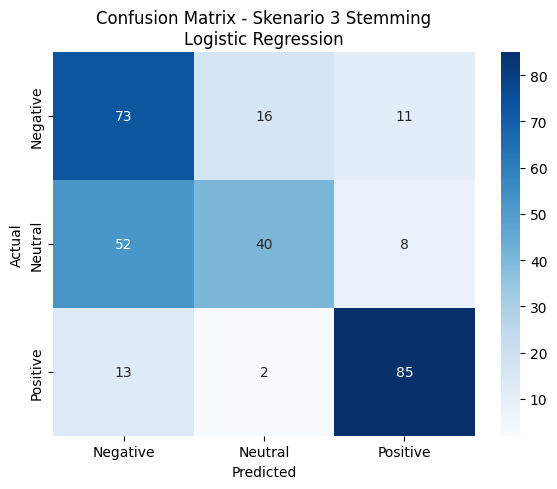


=== Multinomial Naive Bayes ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.59      0.69      0.64       100
     Neutral       0.81      0.38      0.52       100
    Positive       0.66      0.90      0.76       100

    accuracy                           0.66       300
   macro avg       0.69      0.66      0.64       300
weighted avg       0.69      0.66      0.64       300

Confusion Matrix:


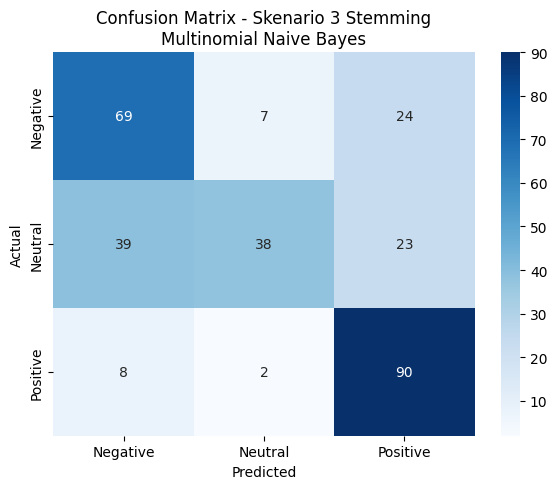


=== Support Vector Machine ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.52      0.86      0.65       100
     Neutral       0.82      0.31      0.45       100
    Positive       0.85      0.82      0.83       100

    accuracy                           0.66       300
   macro avg       0.73      0.66      0.64       300
weighted avg       0.73      0.66      0.64       300

Confusion Matrix:


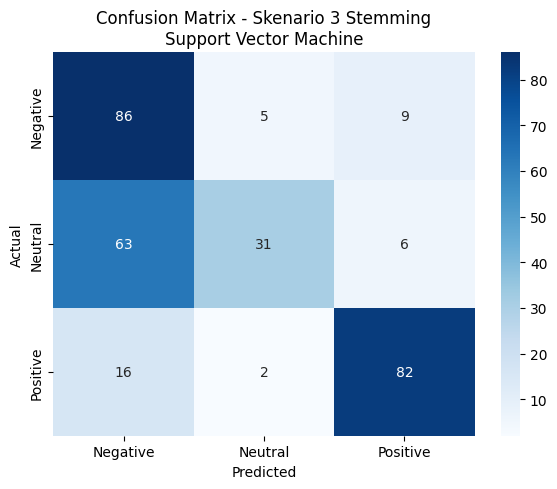


=== Random Forest ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.57      0.66      0.61       100
     Neutral       0.69      0.54      0.61       100
    Positive       0.77      0.82      0.79       100

    accuracy                           0.67       300
   macro avg       0.68      0.67      0.67       300
weighted avg       0.68      0.67      0.67       300

Confusion Matrix:


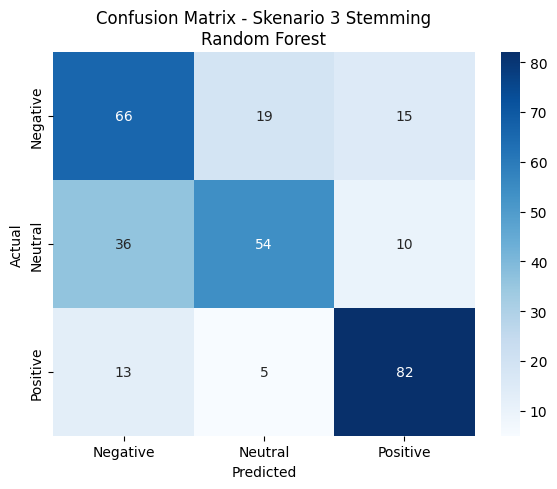


=== XGBoost ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.55      0.64      0.59       100
     Neutral       0.65      0.55      0.59       100
    Positive       0.82      0.80      0.81       100

    accuracy                           0.66       300
   macro avg       0.67      0.66      0.66       300
weighted avg       0.67      0.66      0.66       300

Confusion Matrix:


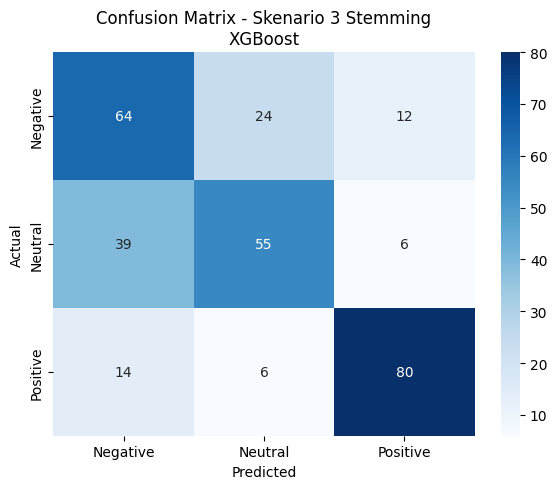


=== Perbandingan Performa Model (Skenario 3 - Stemming) ===
Metric                            Accuracy  F1-score  Precision  Recall  \
Model                   Class                                             
Logistic Regression     Negative       NaN  0.613445   0.528986    0.73   
                        Neutral        NaN  0.506329   0.689655    0.40   
                        Overall   0.660000       NaN        NaN     NaN   
                        Positive       NaN  0.833333   0.817308    0.85   
Multinomial Naive Bayes Negative       NaN  0.638889   0.594828    0.69   
                        Neutral        NaN  0.517007   0.808511    0.38   
                        Overall   0.656667       NaN        NaN     NaN   
                        Positive       NaN  0.759494   0.656934    0.90   
Random Forest           Negative       NaN  0.613953   0.573913    0.66   
                        Neutral        NaN  0.606742   0.692308    0.54   
                        Overall   0.673

In [ ]:
# ==========================================
# Training Model
# ==========================================

models3 = {
    'Logistic Regression'    : LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Support Vector Machine' : SVC(random_state=42),
    'Random Forest'          : RandomForestClassifier(random_state=42),
    'XGBoost'                : XGBClassifier(random_state=42, eval_metric='mlogloss')
}

target_names3 = ['Negative', 'Neutral', 'Positive']
results3 = []

for name, model in models3.items():
    print(f"\n=== {name} ===")

    # train
    model.fit(X3_train_tfidf, y3_train)

    # prediksi
    y3_pred = model.predict(X3_test_tfidf)

    # evaluasi
    report = classification_report(y3_test, y3_pred, target_names=target_names3, output_dict=True)
    accuracy = accuracy_score(y3_test, y3_pred)

    for class_label in target_names3:
        for metric in ['precision', 'recall', 'f1-score', 'support']:
            results3.append({
                'Model' : name,
                'Metric': metric.replace('-score', '-Score').capitalize(),
                'Class' : class_label,
                'Score' : report[class_label][metric]
            })

    results3.append({
        'Model' : name,
        'Metric': 'Accuracy',
        'Class' : 'Overall',
        'Score' : accuracy
    })

    print("Classification Report:")
    print(classification_report(y3_test, y3_pred, target_names=target_names3))

    print("Confusion Matrix:")
    cm3 = confusion_matrix(y3_test, y3_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names3, yticklabels=target_names3)
    plt.title(f'Confusion Matrix - Skenario 3 Stemming\n{name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

# buat dataframe perbandingan hasil
df3 = pd.DataFrame(results3)
pivot3 = df3.pivot_table(index=['Model', 'Class'], columns='Metric', values='Score')
print("\n=== Perbandingan Performa Model (Skenario 3 - Stemming) ===")
print(pivot3)

=== Ringkasan Test Accuracy (Skenario 3 - Stemming) ===
                  Model  Test Accuracy
          Random Forest       0.673333
                XGBoost       0.663333
 Support Vector Machine       0.663333
    Logistic Regression       0.660000
Multinomial Naive Bayes       0.656667


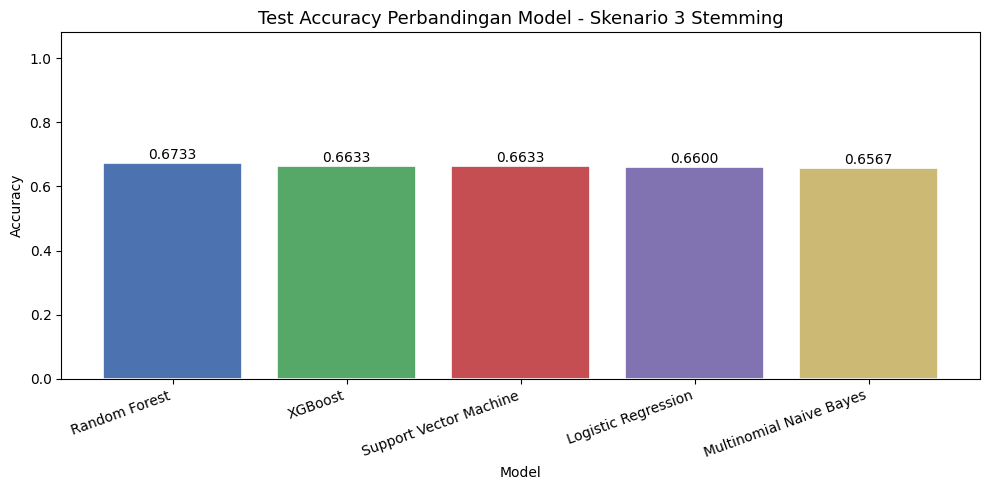

In [ ]:
# ==========================================
# Visualisasi Test Accuracy per Model
# ==========================================

accuracy3_summary = (
    df3[
        (df3['Metric'] == 'Accuracy') &
        (df3['Class']  == 'Overall')
    ][['Model', 'Score']]
    .sort_values('Score', ascending=False)
    .reset_index(drop=True)
)
accuracy3_summary.columns = ['Model', 'Test Accuracy']

print('=== Ringkasan Test Accuracy (Skenario 3 - Stemming) ===')
print(accuracy3_summary.to_string(index=False))

colors3 = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
plt.figure(figsize=(10, 5))
bars3 = plt.bar(
    accuracy3_summary['Model'],
    accuracy3_summary['Test Accuracy'],
    color=colors3[:len(accuracy3_summary)],
    edgecolor='white',
    linewidth=1.2
)
for rect in bars3:
    height = rect.get_height()
    plt.text(
        rect.get_x() + rect.get_width() / 2.,
        height + 0.003,
        f'{height:.4f}',
        ha='center', va='bottom', fontsize=10
    )
plt.title('Test Accuracy Perbandingan Model - Skenario 3 Stemming', fontsize=13)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1.08)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# Skenario 4 - Addien

In [ ]:
# ==========================================
# SKENARIO 4 - Preprocessing with IndoNLP Slang Normalizaton, CountVectorizer plus n-Gram
# ==========================================

x4_train = x_train_final.copy()
y4_train = y_train_final.copy()

x4_test = X_test.copy()
y4_test = y_test.copy()

print("Jumlah data training :", len(x4_train))
print("Jumlah data testing  :", len(x4_test))

Jumlah data training : 2700
Jumlah data testing  : 300


In [ ]:
# ==========================================
# Preprocessing: Slang Normalization menggunakan IndoNLP
# Pipeline: Indo NLP - Slang Normalization
# ==========================================

# IndoNLP : slang normalization
# Mengubah kata-kata tidak baku (slang) menjadi bentuk formal
x4_train = (x4_train.astype(str).apply(replace_slang))
x4_test = (x4_test.astype(str).apply(replace_slang))

# Comparison Visualization : Before & After IndoNLP
# Membandingkan 10 data pertama sebelum dan sesudah normalisasi
comparison = pd.DataFrame({
    'Original': x_train_final.head(10),
    'Normalized': x4_train.head(10)
})
display(comparison)

,Original,Normalized
0,Hidup JKW!!\n\n🤥,Hidup JKW!!\n\n🤥
1,sudah Itu pasti,sudah Itu pasti
2,Imf dan warld bank adalah jebakan financial un...,Imf dan warld bank adalah jebakan financial un...
3,"Rupiah jatuh ke level teeburuk sepanjang masa,...","Rupiah jatuh ke level teeburuk sepanjang masa,..."
4,Pemikiran Majapahit,Pemikiran Majapahit
5,Saya lebih percaya Prof Gema Goeyardi dibandin...,Saya lebih percaya Prof Gema Goeyardi dibandin...
6,Gue sumpahin loe gedenya jadi menteri yg jujur 🎉,Gue sumpahin lo gedenya jadi menteri yang jujur 🎉
7,Benixx itu pendukung bayaran pemerintah. Kan p...,Benixx itu pendukung bayaran pemerintah. Kan p...
8,​Pemerintah secara konsisten mengawal keberlan...,​Pemerintah secara konsisten mengawal keberlan...
9,Bener kamu dek,benar kamu dek


In [ ]:
# ==========================================
# CountVectorizer & N-Gram (Unigram, Bigram, Trigram)
# ==========================================

# 3.1 Unigram Vectorization
# Mengubah teks menjadi fitur numerik berbasis kata tunggal (1-gram)
cv_uni = CountVectorizer(ngram_range=(1,1))

# 4.1 Transformasi menjadi angka teks dengan fitur unigram
# Fit pada data training, lalu transform training & testing
x4_train_uni = cv_uni.fit_transform(x4_train)
x4_test_uni = cv_uni.transform(x4_test)

# 3.2 Bigram Vectorization
# Menambahkan penggunaan kombinasi kata (1 kata + 2 kata berurutan)
cv_bi = CountVectorizer(ngram_range=(1,2))

# 4.2 Transformasi menjadi angka teks dengan fitur unigram + bigram
# Fit pada data training, lalu transform training & testing
x4_train_bi = cv_bi.fit_transform(x4_train)
x4_test_bi = cv_bi.transform(x4_test)

# 3.3 Trigram Vectorization
# Menambahkan penggunaan kombinasi hingga 3 kata berurutan
cv_tri = CountVectorizer(ngram_range=(1,3))

# 4.3 Transformasi teks menjadi angka dengan fitur unigram + bigram + trigram
# Fit pada data training, lalu transform training & testing
x4_train_tri = cv_tri.fit_transform(x4_train)
x4_test_tri = cv_tri.transform(x4_test)

print("Unigram shape:", x4_train_uni.shape)
print("Bigram shape:", x4_train_bi.shape)
print("Trigram shape:", x4_train_tri.shape)

Unigram shape: (2700, 5868)
Bigram shape: (2700, 31155)
Trigram shape: (2700, 61709)




CONFIG : Unigram

=== Logistic Regression ===
Accuracy : 0.6700

Classification Report:
              precision    recall  f1-score   support

    Negative       0.54      0.68      0.60       100
     Neutral       0.70      0.51      0.59       100
    Positive       0.80      0.82      0.81       100

    accuracy                           0.67       300
   macro avg       0.68      0.67      0.67       300
weighted avg       0.68      0.67      0.67       300



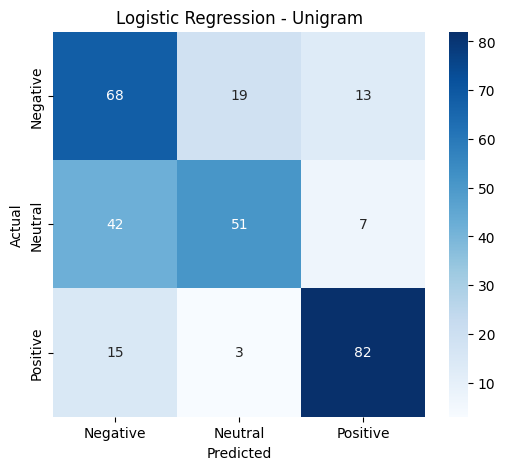


=== Multinomial Naive Bayes ===
Accuracy : 0.6700

Classification Report:
              precision    recall  f1-score   support

    Negative       0.59      0.75      0.66       100
     Neutral       0.84      0.38      0.52       100
    Positive       0.69      0.88      0.78       100

    accuracy                           0.67       300
   macro avg       0.71      0.67      0.65       300
weighted avg       0.71      0.67      0.65       300



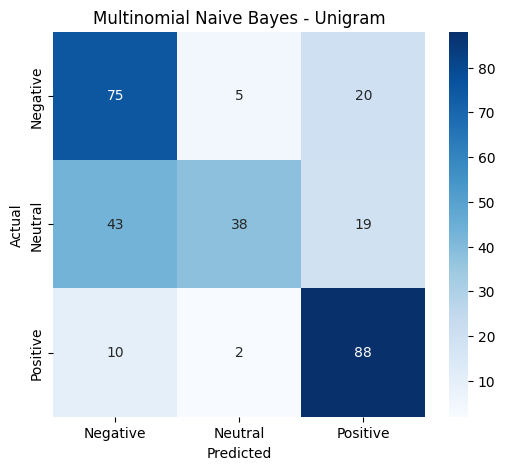


=== Support Vector Machine ===
Accuracy : 0.6867

Classification Report:
              precision    recall  f1-score   support

    Negative       0.59      0.64      0.61       100
     Neutral       0.67      0.61      0.64       100
    Positive       0.81      0.81      0.81       100

    accuracy                           0.69       300
   macro avg       0.69      0.69      0.69       300
weighted avg       0.69      0.69      0.69       300



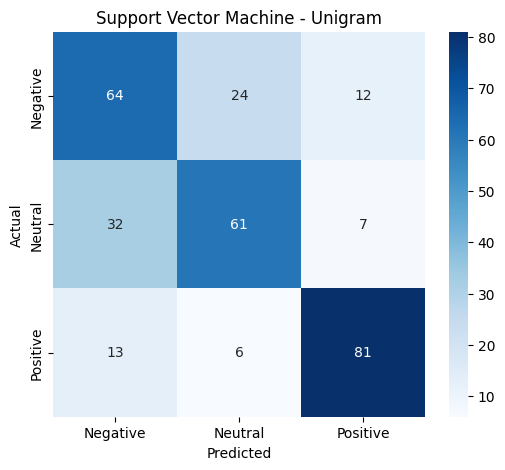


=== Random Forest ===
Accuracy : 0.7100

Classification Report:
              precision    recall  f1-score   support

    Negative       0.62      0.72      0.67       100
     Neutral       0.77      0.56      0.65       100
    Positive       0.77      0.85      0.81       100

    accuracy                           0.71       300
   macro avg       0.72      0.71      0.71       300
weighted avg       0.72      0.71      0.71       300



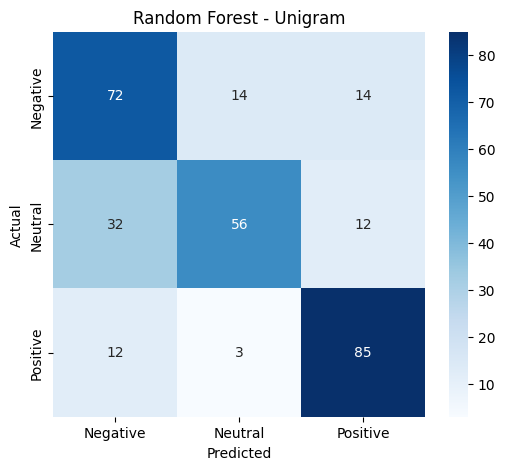


=== XGBoost ===
Accuracy : 0.6900

Classification Report:
              precision    recall  f1-score   support

    Negative       0.56      0.68      0.61       100
     Neutral       0.70      0.53      0.60       100
    Positive       0.84      0.86      0.85       100

    accuracy                           0.69       300
   macro avg       0.70      0.69      0.69       300
weighted avg       0.70      0.69      0.69       300



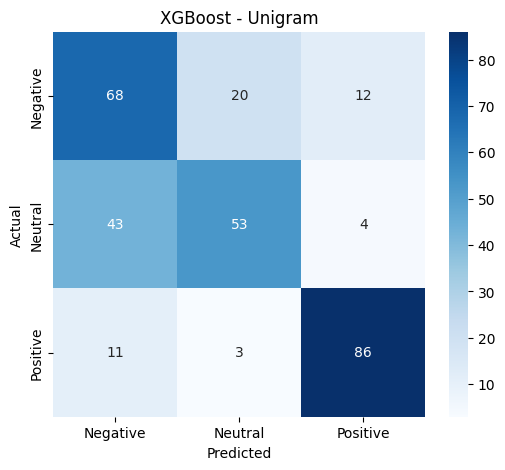



CONFIG : Unigram + Bigram

=== Logistic Regression ===
Accuracy : 0.6900

Classification Report:
              precision    recall  f1-score   support

    Negative       0.57      0.71      0.63       100
     Neutral       0.71      0.52      0.60       100
    Positive       0.82      0.84      0.83       100

    accuracy                           0.69       300
   macro avg       0.70      0.69      0.69       300
weighted avg       0.70      0.69      0.69       300



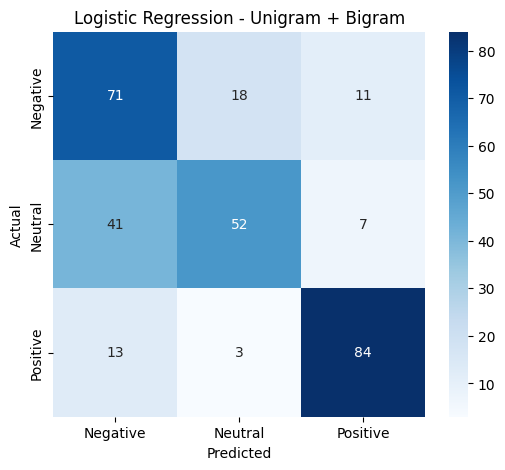


=== Multinomial Naive Bayes ===
Accuracy : 0.6300

Classification Report:
              precision    recall  f1-score   support

    Negative       0.56      0.65      0.60       100
     Neutral       0.82      0.33      0.47       100
    Positive       0.64      0.91      0.75       100

    accuracy                           0.63       300
   macro avg       0.67      0.63      0.61       300
weighted avg       0.67      0.63      0.61       300



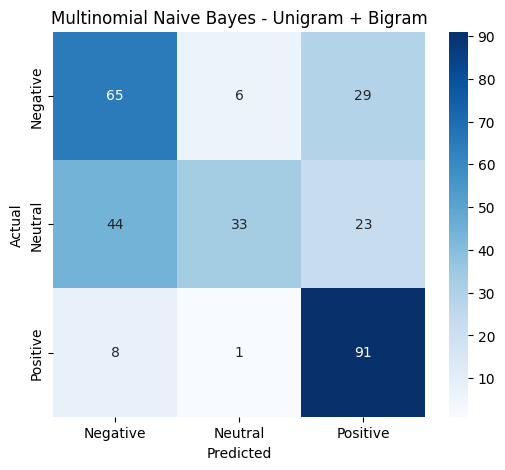


=== Support Vector Machine ===
Accuracy : 0.6800

Classification Report:
              precision    recall  f1-score   support

    Negative       0.59      0.58      0.59       100
     Neutral       0.63      0.69      0.66       100
    Positive       0.83      0.77      0.80       100

    accuracy                           0.68       300
   macro avg       0.68      0.68      0.68       300
weighted avg       0.68      0.68      0.68       300



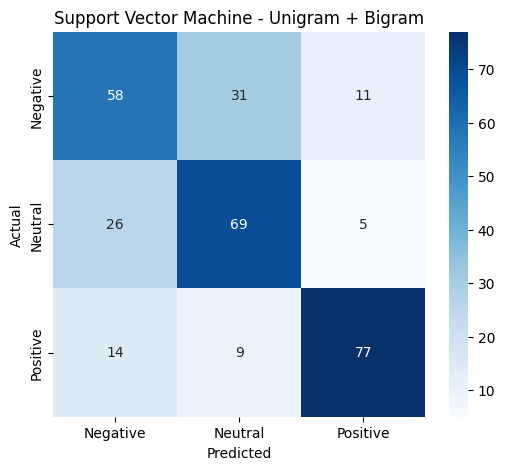


=== Random Forest ===
Accuracy : 0.7067

Classification Report:
              precision    recall  f1-score   support

    Negative       0.62      0.68      0.65       100
     Neutral       0.71      0.60      0.65       100
    Positive       0.80      0.84      0.82       100

    accuracy                           0.71       300
   macro avg       0.71      0.71      0.71       300
weighted avg       0.71      0.71      0.71       300



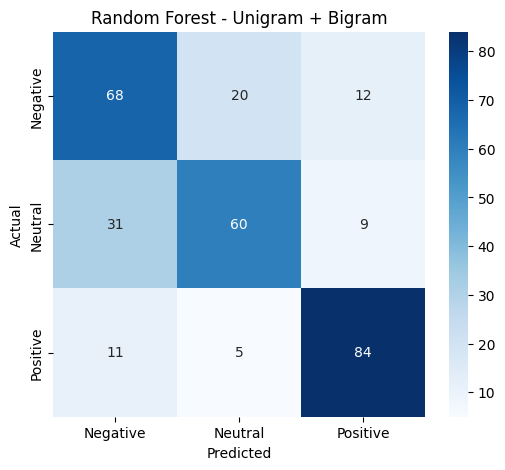


=== XGBoost ===
Accuracy : 0.6967

Classification Report:
              precision    recall  f1-score   support

    Negative       0.57      0.70      0.63       100
     Neutral       0.71      0.55      0.62       100
    Positive       0.84      0.84      0.84       100

    accuracy                           0.70       300
   macro avg       0.71      0.70      0.70       300
weighted avg       0.71      0.70      0.70       300



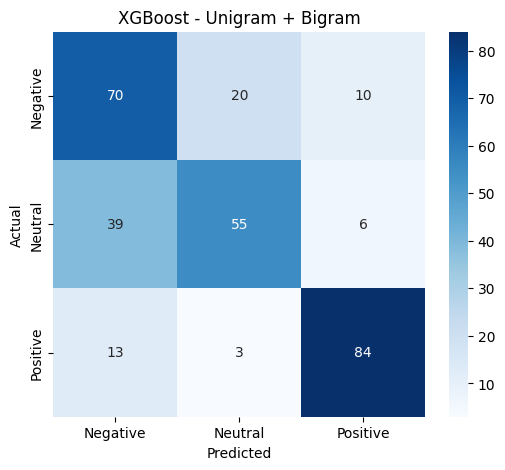



CONFIG : Unigram + Bigram + Trigram

=== Logistic Regression ===
Accuracy : 0.6900

Classification Report:
              precision    recall  f1-score   support

    Negative       0.58      0.71      0.64       100
     Neutral       0.71      0.53      0.61       100
    Positive       0.81      0.83      0.82       100

    accuracy                           0.69       300
   macro avg       0.70      0.69      0.69       300
weighted avg       0.70      0.69      0.69       300



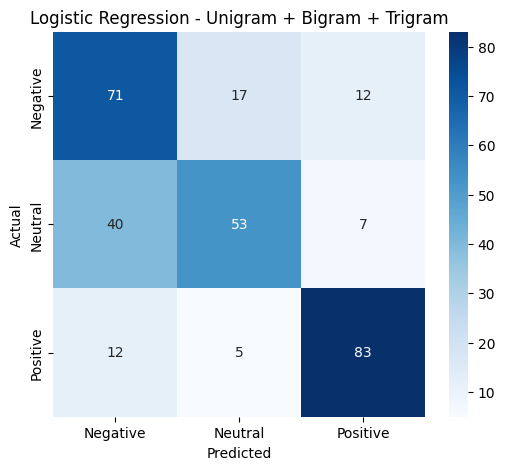


=== Multinomial Naive Bayes ===
Accuracy : 0.6167

Classification Report:
              precision    recall  f1-score   support

    Negative       0.54      0.63      0.58       100
     Neutral       0.82      0.31      0.45       100
    Positive       0.62      0.91      0.74       100

    accuracy                           0.62       300
   macro avg       0.66      0.62      0.59       300
weighted avg       0.66      0.62      0.59       300



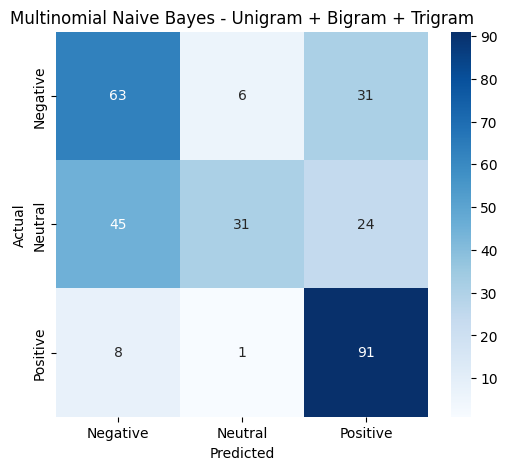


=== Support Vector Machine ===
Accuracy : 0.6733

Classification Report:
              precision    recall  f1-score   support

    Negative       0.60      0.55      0.58       100
     Neutral       0.61      0.73      0.67       100
    Positive       0.82      0.74      0.78       100

    accuracy                           0.67       300
   macro avg       0.68      0.67      0.67       300
weighted avg       0.68      0.67      0.67       300



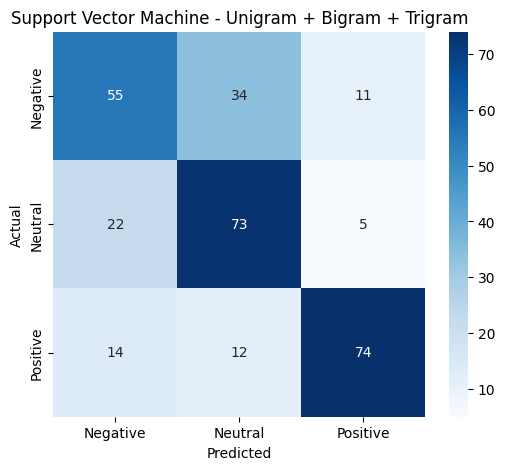


=== Random Forest ===
Accuracy : 0.6900

Classification Report:
              precision    recall  f1-score   support

    Negative       0.59      0.66      0.63       100
     Neutral       0.67      0.58      0.62       100
    Positive       0.81      0.83      0.82       100

    accuracy                           0.69       300
   macro avg       0.69      0.69      0.69       300
weighted avg       0.69      0.69      0.69       300



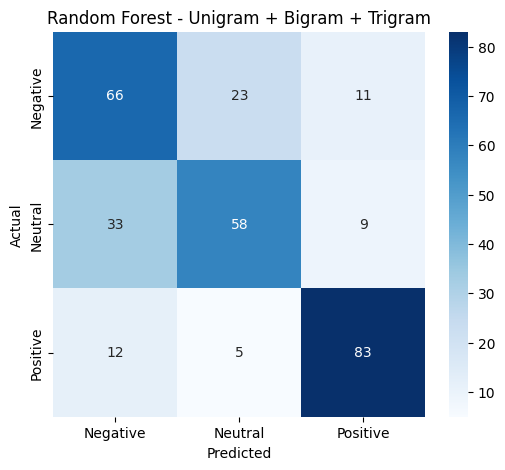


=== XGBoost ===
Accuracy : 0.6967

Classification Report:
              precision    recall  f1-score   support

    Negative       0.56      0.73      0.63       100
     Neutral       0.72      0.51      0.60       100
    Positive       0.86      0.85      0.85       100

    accuracy                           0.70       300
   macro avg       0.71      0.70      0.70       300
weighted avg       0.71      0.70      0.70       300



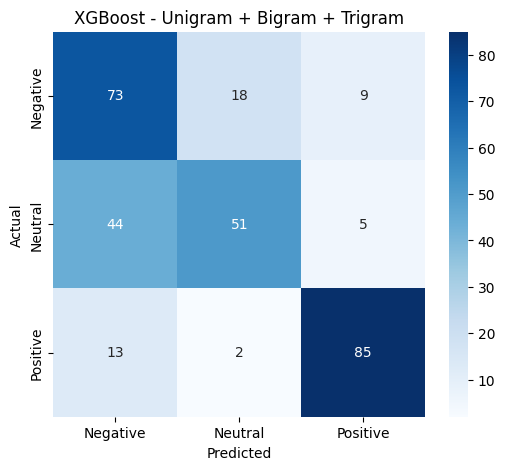


=== MODEL PERFORMANCE COMPARISON ===


Metric                                                       Accuracy  \
Configs                    Model                   Class                
Unigram                    Logistic Regression     Negative       NaN   
                                                   Neutral        NaN   
                                                   Overall   0.670000   
                                                   Positive       NaN   
                           Multinomial Naive Bayes Negative       NaN   
                                                   Neutral        NaN   
                                                   Overall   0.670000   
                                                   Positive       NaN   
                           Random Forest           Negative       NaN   
                                                   Neutral        NaN   
                                                   Overall   0.710000   
                                                   Positive       NaN   
                           Support Vector Machine  Negative       NaN   
                                                   Neutral        NaN   
                                                   Overall   0.686667   
                                                   Positive       NaN   
                           XGBoost                 Negative       NaN   
                                                   Neutral        NaN   
                                                   Overall   0.690000   
                                                   Positive       NaN   
Unigram + Bigram           Logistic Regression     Negative       NaN   
                                                   Neutral        NaN   
                                                   Overall   0.690000   
                                                   Positive       NaN   
                           Multinomial Naive Bayes Negative       NaN   
                                                   Neutral        NaN   
                                                   Overall   0.630000   
                                                   Positive       NaN   
                           Random Forest           Negative       NaN   
                                                   Neutral        NaN   
                                                   Overall   0.706667   
                                                   Positive       NaN   
                           Support Vector Machine  Negative       NaN   
                                                   Neutral        NaN   
                                                   Overall   0.680000   
                                                   Positive       NaN   
                           XGBoost                 Negative       NaN   
                                                   Neutral        NaN   
                                                   Overall   0.696667   
                                                   Positive       NaN   
Unigram + Bigram + Trigram Logistic Regression     Negative       NaN   
                                                   Neutral        NaN   
                                                   Overall   0.690000   
                                                   Positive       NaN   
                           Multinomial Naive Bayes Negative       NaN   
                                                   Neutral        NaN   
                                                   Overall   0.616667   
                                                   Positive       NaN   
                           Random Forest           Negative       NaN   
                                                   Neutral        NaN   
                                                   Overall   0.690000   
                                                   Positive       NaN   
                           Support Vector Machine  Negativ

In [ ]:
# ==========================================
# Training Model
# ==========================================

# Model
models4 = {
    'Logistic Regression'    : LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Support Vector Machine' : SVC(random_state=42),
    'Random Forest'          : RandomForestClassifier(random_state=42),
    'XGBoost'                : XGBClassifier(random_state=42, eval_metric='mlogloss')
}

# Target & Result
target_names4 = ['Negative', 'Neutral', 'Positive']
results4 = []

# Configs comparison
configs  = {
    'Unigram': (x4_train_uni, x4_test_uni),
    'Unigram + Bigram': (x4_train_bi, x4_test_bi),
    'Unigram + Bigram + Trigram': ( x4_train_tri, x4_test_tri)
}

for configs_name, (x4_train_vec, x4_test_vec) in configs .items():

    print("\n")
    print("=" * 60)
    print(f"CONFIG : {configs_name}")
    print("=" * 60)

    for model_name, model in models4.items():

        print(f"\n=== {model_name} ===")

        # Train
        model.fit(x4_train_vec, y4_train)

        # Predict
        y4_pred = model.predict(x4_test_vec)

        # Evaluation
        report = classification_report( y4_test,y4_pred, target_names=target_names4, output_dict=True)

        accuracy = accuracy_score(y4_test,y4_pred)

        # Store metrics
        for class_label in target_names4:
            for metric in ['precision', 'recall', 'f1-score', 'support']:
                results4.append({
                    'Configs': configs_name,
                    'Model': model_name,
                    'Metric': metric.replace('-', '-').capitalize(),
                    'Class': class_label,
                    'Score': report[class_label][metric]
                })

        # Accuracy
        results4.append({
            'Configs': configs_name,
            'Model': model_name,
            'Metric': 'Accuracy',
            'Class': 'Overall',
            'Score': accuracy
        })

        print(f"Accuracy : {accuracy:.4f}")

        print("\nClassification Report:")
        print(
            classification_report(
                y4_test,
                y4_pred,
                target_names=target_names4
            )
        )

        # Confusion Matrix
        cm = confusion_matrix(y4_test,y4_pred)

        plt.figure(figsize=(6,5))

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names4, yticklabels=target_names4)
        plt.title(f'{model_name} - {configs_name}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()



# buat dataframe perbandingan hasil
comparison_df = pd.DataFrame(results4)
pivot_table = comparison_df.pivot_table(index=['Configs', 'Model', 'Class'], columns='Metric', values='Score')
print("\n=== MODEL PERFORMANCE COMPARISON ===")

display(pivot_table)

In [ ]:
# buat dataframe perbandingan hasil accurancy saja
accuracy_table = comparison_df[comparison_df['Metric'] == 'Accuracy']

accuracy_table = accuracy_table.pivot_table(index='Model',columns='Configs',values='Score')

display(accuracy_table)

Configs,Unigram,Unigram + Bigram,Unigram + Bigram + Trigram
Model,,,
Logistic Regression,0.670000,0.690000,0.690000
Multinomial Naive Bayes,0.670000,0.630000,0.616667
Random Forest,0.710000,0.706667,0.690000
Support Vector Machine,0.686667,0.680000,0.673333
XGBoost,0.690000,0.696667,0.696667


# Skenario 5 - Farras

In [ ]:
# ==========================================
# SKENARIO 5 - Preprocessing with NLP-ID StopWords and Stemming
# ==========================================

x5_train = x_train_final.copy()
y5_train = y_train_final.copy()

x5_test = X_test.copy()
y5_test = y_test.copy()

print("Jumlah data training :", len(x5_train))
print("Jumlah data testing  :", len(x5_test))

Jumlah data training : 2700
Jumlah data testing  : 300


In [ ]:
stopword_remover = StopWord()
lemmatizer = Lemmatizer()

def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    #Stemming
    text = lemmatizer.lemmatize(text)
    #Stopwords
    text = stopword_remover.remove_stopword(text)

    return text

x5_train_processed = x5_train.apply(preprocess_text)
x5_test_processed = x5_test.apply(preprocess_text)

print("\n--- Preprocessed comment sample ---")
print(x5_train_processed.head(5))
print("\n--- Non Preprocessed comment sample ---")
print(x5_train.head(5))


--- Preprocessed comment sample ---
0                                            hidup jkw
1                                                     
2    imf warld bank jebak financial dikte atur daul...
3    rupiah jatuh level teeburuk ihsg perosok lbh b...
4                                      pikir majapahit
Name: comment, dtype: str

--- Non Preprocessed comment sample ---
0                                     Hidup JKW!!\n\n🤥
1                                      sudah Itu pasti
2    Imf dan warld bank adalah jebakan financial un...
3    Rupiah jatuh ke level teeburuk sepanjang masa,...
4                                  Pemikiran Majapahit
Name: comment, dtype: str


In [ ]:
tfidf_vectorizer_processed5 = TfidfVectorizer(max_features=5000)

x5_train_tfidf = tfidf_vectorizer_processed5.fit_transform(x5_train_processed)
x5_test_tfidf = tfidf_vectorizer_processed5.transform(x5_test_processed)

print(f"Shape of X5_train_tfidf: {x5_train_tfidf.shape}")
print(f"Shape of X5_test_tfidf: {x5_test_tfidf.shape}")

Shape of X5_train_tfidf: (2700, 4421)
Shape of X5_test_tfidf: (300, 4421)


In [ ]:
models = {
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'SVM': SVC(kernel='linear', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}


=== XGBoost ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.60      0.53      0.56       100
     Neutral       0.61      0.71      0.66       100
    Positive       0.81      0.78      0.80       100

    accuracy                           0.67       300
   macro avg       0.68      0.67      0.67       300
weighted avg       0.68      0.67      0.67       300

Confusion Matrix:


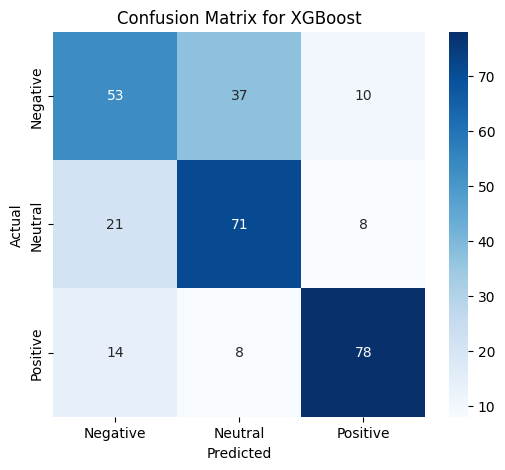


=== Logistic Regression ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.52      0.79      0.63       100
     Neutral       0.75      0.36      0.49       100
    Positive       0.84      0.85      0.85       100

    accuracy                           0.67       300
   macro avg       0.70      0.67      0.65       300
weighted avg       0.70      0.67      0.65       300

Confusion Matrix:


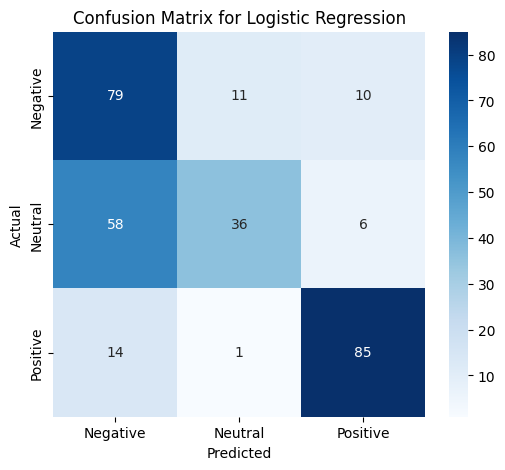


=== Naive Bayes ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.56      0.66      0.61       100
     Neutral       0.79      0.38      0.51       100
    Positive       0.66      0.89      0.76       100

    accuracy                           0.64       300
   macro avg       0.67      0.64      0.63       300
weighted avg       0.67      0.64      0.63       300

Confusion Matrix:


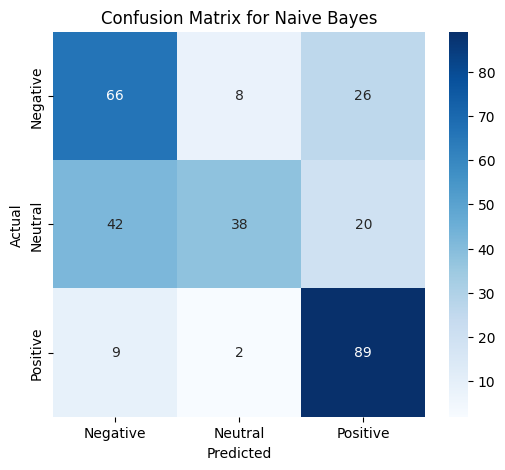


=== SVM ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.53      0.80      0.63       100
     Neutral       0.77      0.36      0.49       100
    Positive       0.83      0.84      0.84       100

    accuracy                           0.67       300
   macro avg       0.71      0.67      0.65       300
weighted avg       0.71      0.67      0.65       300

Confusion Matrix:


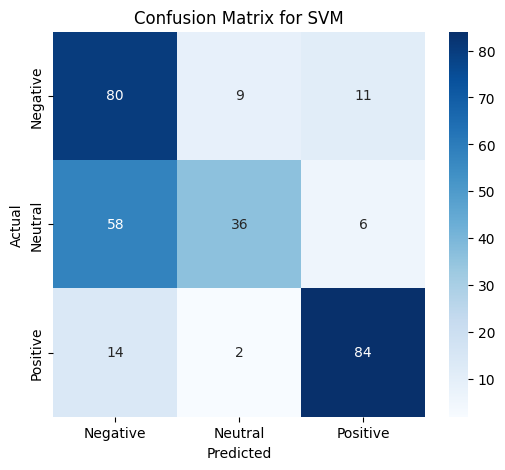


=== Random Forest ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.58      0.59      0.58       100
     Neutral       0.66      0.56      0.61       100
    Positive       0.75      0.85      0.80       100

    accuracy                           0.67       300
   macro avg       0.66      0.67      0.66       300
weighted avg       0.66      0.67      0.66       300

Confusion Matrix:


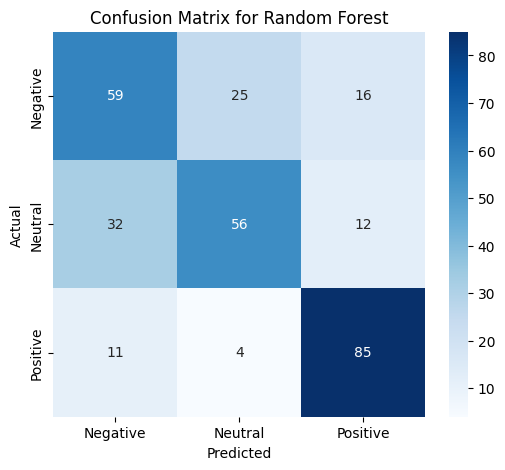


=== Model Performance Comparison ===
Metric                        Accuracy  F1-Score  Precision  Recall  Support
Model               Class                                                   
Logistic Regression Negative       NaN  0.629482   0.523179    0.79    100.0
                    Neutral        NaN  0.486486   0.750000    0.36    100.0
                    Overall   0.666667       NaN        NaN     NaN      NaN
                    Positive       NaN  0.845771   0.841584    0.85    100.0
Naive Bayes         Negative       NaN  0.608295   0.564103    0.66    100.0
                    Neutral        NaN  0.513514   0.791667    0.38    100.0
                    Overall   0.643333       NaN        NaN     NaN      NaN
                    Positive       NaN  0.757447   0.659259    0.89    100.0
Random Forest       Negative       NaN  0.584158   0.578431    0.59    100.0
                    Neutral        NaN  0.605405   0.658824    0.56    100.0
                    Overall   0.666667

In [ ]:
results5 = []
reports5 = {}

datasets5 = {
    'Preprocessed (nlp-id)': (x5_train_tfidf, x5_test_tfidf)
}

target_names = ['Negative', 'Neutral', 'Positive'] # Define target_names here

for name, model in models.items():
    print(f"\n=== {name} ===")
    # Train the model
    model.fit(x5_train_tfidf, y5_train)

    # Make predictions
    y_pred = model.predict(x5_test_tfidf)

    # Evaluate the model
    print("Classification Report:")
    report_str = classification_report(y5_test, y_pred, target_names=target_names)
    print(report_str)

    # Generate the dictionary report for parsing metrics
    report = classification_report(y5_test, y_pred, target_names=target_names, output_dict=True)
    accuracy = accuracy_score(y5_test, y_pred)
    reports5[name] = report

    # Store results for each class
    for class_label in target_names:
        results5.append({
            'Model': name,
            'Metric': 'Precision',
            'Class': class_label,
            'Score': report[class_label]['precision']
        })
        results5.append({
            'Model': name,
            'Metric': 'Recall',
            'Class': class_label,
            'Score': report[class_label]['recall']
        })
        results5.append({
            'Model': name,
            'Metric': 'F1-Score',
            'Class': class_label,
            'Score': report[class_label]['f1-score']
        })
        results5.append({
            'Model': name,
            'Metric': 'Support',
            'Class': class_label,
            'Score': report[class_label]['support']
        })

    # Store overall accuracy
    results5.append({
        'Model': name,
        'Metric': 'Accuracy',
        'Score': accuracy,
        'Class': 'Overall',
    })

    print("Confusion Matrix:")
    cm = confusion_matrix(y5_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Create a DataFrame from the corrected results5 list
comparison5_df = pd.DataFrame(results5)

# Pivot the table for better readability
pivot_table5 = comparison5_df.pivot_table(index=['Model', 'Class'], columns='Metric', values='Score')

print("\n=== Model Performance Comparison ===")
print(pivot_table5)